In [1]:
!pip install pydoe

In [2]:
import numpy as np
import pandas as pd
from pydoe import fullfact
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import minmax_scale
from scipy import stats 

**pydoe** (Python Design of Experiments) es una libreria que genera matrices de diseno
estructuradas: dada una lista de niveles por factor, `fullfact([a, b, c])` devuelve todas las
$a \times b \times c$ combinaciones de tratamientos sin que tengamos que escribirlas a mano.

---

## Estructura del notebook

Este notebook cubre tres aproximaciones al analisis de disenos factoriales:

| Parte | Tema | Metodo clave |
|-------|------|--------------|
| 1 | Diseno factorial completo (3 factores) | `fullfact`, interaccion, ANOVA tipo II |
| 2 | Diseno factorial por bloques | ANOVA manual con variable de bloqueo |
| 3 | Analisis estadistico clasico | Tests no-parametricos, comparaciones por pares |

En todos los casos trabajamos con datos **simulados** con pesos conocidos, lo que nos
permite verificar si el analisis estadistico recupera la estructura real del modelo.

# Parte 1: Diseño Factorial

Para abrir en colab: <a target="_blank" href="https://githubtocolab.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/Ayudantias/Ayudantia8_DisenoExperimentalFactorial.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## ¿Por qué es necesario realizar un diseño experimental?
1. Un diseño experimental nos permite generar un **plan** de nuestro experimento. Lo que nos permite probar las diferentes combinaciones de nuestros datos de forma sistemática.
2. En ciertos casos, por ejemplo un diseño factorial, diseños experimentales permiten entender mejor el sistema (interacciones).
3. Los diseños experimentales, si son bien realizados, permiten disminuir la cantidad de experimentos a realizar.
4. En casos particulares, los diseños experimentales permiten predecir futuros experimentos que permitan entender mejor el comportamiento del sistema.
    - Ver: [Bayesian Experimental Design](https://arxiv.org/pdf/2302.14545) y aplicaciones como [Diseño de comunidades Bacterianas](https://www.biorxiv.org/content/10.1101/2025.03.03.641341v1.full.pdf+html)

Así, un diseño experimental provee de herramientas para realizar mejores experimentos y planificarnos en nuestro día a día en el laboratorio.

Por otra parte, el área del diseño experimental no solo provee de métodos de formulación de un *setting* experimental, sino de herramientas que permitan analizarlos de mejor manera -las cuales iremos discutinedo a lo largo de al unidad.

### Diseno Factorial Completo

El diseno factorial completo, como su nombre menciona, genera todas las combinaciones entre las variables (como el factorial $!$). Esto nos permite evaluar como se interactuan todos los niveles de las variables que poseemos a nuestra disposicion. 

Asi, por ejemplo, teniendo 3 factores $A, B, C$ y 2, 3, 4 niveles por factor. Se deben realizar $2 \times 3 \times 4 \times n$ experimentos, considerando $n$ la cantidad de repeticiones.

**¿Por que son importantes las repeticiones?**
Las repeticiones permiten **estimar el error experimental** ($MS_E$) de forma independiente de los efectos de los tratamientos. Sin repeticiones, el termino de error quedaria confundido con las interacciones de orden superior, y no podriamos calcular los estadisticos $F$ para ninguna fuente de variacion. Con $n \geq 2$ replicas por celda, $SS_E = \sum_{ijk}(y_{ijk} - \bar y_{ij\cdot})^2$ tiene $ab(n-1)$ grados de libertad (Montgomery, 2017, Eq. 5.5).

In [3]:
# Implementacion en python
levels = [2,3,4] # niveles por factor
design = fullfact(levels) # matriz de diseño
rep = 3
X = np.repeat(design, rep, axis=0)
df = pd.DataFrame(X, columns=['A1', 'B1', 'C1']).astype('int').astype('category') # definimos como categorias
display(design) 
display(df)

array([[0., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 1., 0.],
       [0., 2., 0.],
       [1., 2., 0.],
       [0., 0., 1.],
       [1., 0., 1.],
       [0., 1., 1.],
       [1., 1., 1.],
       [0., 2., 1.],
       [1., 2., 1.],
       [0., 0., 2.],
       [1., 0., 2.],
       [0., 1., 2.],
       [1., 1., 2.],
       [0., 2., 2.],
       [1., 2., 2.],
       [0., 0., 3.],
       [1., 0., 3.],
       [0., 1., 3.],
       [1., 1., 3.],
       [0., 2., 3.],
       [1., 2., 3.]])

,A1,B1,C1
0,0,0,0
1,0,0,0
2,0,0,0
3,1,0,0
4,1,0,0
...,...,...,...
67,0,2,3
68,0,2,3
69,1,2,3
70,1,2,3


`fullfact([2, 3, 4])` devuelve una matriz de $2 \times 3 \times 4 = 24$ filas, una por combinacion
de tratamientos. Cada fila es un **corrida experimental** con los niveles de cada factor codificados
como enteros desde 0. Al repetir 3 veces con `np.repeat(..., 3)` obtenemos 72 filas totales.

Las columnas se convierten a variables categoricas (`dtype='category'`) para que statsmodels las
trate como factores nominales en la formula ANOVA, no como variables numericas.

In [4]:
### simulamos nuestros datos
datos_min_max = df.copy()
datos_min_max = datos_min_max.apply(lambda x: minmax_scale(x, feature_range=(-1, 1)))

w = {
    'w1': 0.5, 'w2': 4, 'w3': 3,
    'w12': 1, 'w13': 0.01, 'w23': 1.2,
    'w123': 6
}
# la barra \ es para continuar la linea


y = 1.5 * datos_min_max['A1'] * w['w1'] + datos_min_max['B1'] * w['w2'] + datos_min_max['C1'] * w['w3'] + \
    datos_min_max['A1'] * datos_min_max['B1'] * w['w12'] + \
    datos_min_max['A1'] * datos_min_max['C1'] * w['w13'] + \
    datos_min_max['B1'] * datos_min_max['C1'] * w['w23'] + \
    datos_min_max['A1'] * datos_min_max['B1'] * datos_min_max['C1'] * w['w123'] + \
    np.random.normal(0, 0.1, len(datos_min_max)) # error aleatorio
    
df['y'] = y
display(df)

,A1,B1,C1,y
0,0,0,0,-11.554214
1,0,0,0,-11.578417
2,0,0,0,-11.600740
3,1,0,0,-0.008790
4,1,0,0,-0.068360
...,...,...,...,...
67,0,2,3,0.549713
68,0,2,3,0.437117
69,1,2,3,15.976428
70,1,2,3,15.876340


Los datos se generan con el modelo lineal de efectos fijos (Montgomery, 2017, Eq. 5.1 generalizado
a 3 factores):

$$y = w_1 A + w_2 B + w_3 C + w_{12} AB + w_{13} AC + w_{23} BC + w_{123} ABC + \epsilon$$

con $\epsilon \sim \mathcal{N}(0,\, 0.01)$ y pesos $w_1 = 0.75,\ w_2 = 4,\ w_3 = 3,\ w_{12} = 1,\
w_{13} = 0.01,\ w_{23} = 1.2,\ w_{123} = 6$.

Los factores se escalan a $[-1, 1]$ antes de aplicar los pesos para que los coeficientes sean
comparables entre si. 

## Visualización de experimentos
> Genere las curvas de respuesta entre las variables $x_1$, $x_2$ y la respuesta $y$. Para ello, mantenga $x_3 = 0$. ¿Es posible visualizar interacción entre $x_1$ y $x_2$? ¿Ocurre lo mismo entre $x_1$ y $x_3$?

En este caso poseemos dos opciones, y presentaremos las dos 😎.


### Caso continuo

En el caso de que las variables explicativas sean continuas, es posible realizar una superficie de respuesta basada en una regresión lineal -u otro tipo de modelo- para estimar el efecto e interacción de las variables sobre la variable de de respuesta. Debido a limitaciones de software y visualización, se realizan gráficas en 3D donde los ejes X e Y corresponden a las variables explicativas, mientras que el eje Z la de respuesta.

Para la superficie de respuesta fijamos $x_3 = 0$ y variamos $x_1, x_2$ en una malla de 100x100
puntos. La respuesta se calcula con los mismos pesos del modelo generador.

**Como interpretar la superficie 3D:**
- **Plano plano** (sin curvatura): no hay interaccion entre las dos variables en el eje X e Y.
- **Plano torcido o curvado**: hay interaccion; el efecto de un factor depende del nivel del otro
  (Montgomery, 2017, Figs. 5.5-5.6).

Con $w_{12} = 1$ y $w_{13} = 0.01$, esperamos que la superficie $x_1$-$x_2$ muestre algo de
inclinacion (interaccion moderada), mientras que la $x_1$-$x_3$ sea casi plana.

In [5]:
###
import plotly.express as px
import plotly.graph_objects as go
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D  

xi = np.linspace(-1, 1, 100) # variable x1
yi = np.linspace(-1, 1, 100) # variable x2
zi = 0 # variable x3 <- = 0

Xi, Yi = np.meshgrid(xi, yi)
response = 1.5 * Xi * w['w1'] + Yi * w['w2'] + zi * w['w3'] + \
    Xi * Yi * w['w12'] + \
    Xi * zi * w['w13'] + \
    Yi * zi * w['w23'] + \
    Xi * Yi * zi * w['w123'] 

fig = go.Figure(go.Surface(x = xi, y = yi, z = response))
fig.update_layout(scene = dict(xaxis_title='X', yaxis_title='Y', zaxis_title='response'),
                      autosize=False, width=1000, height=1000,
                   margin=dict(
                            l=50,
                            r=50,
                            b=100,
                            t=100,
                            pad=4)
    )
fig.show()


In [6]:
xi = np.linspace(-1, 1, 100)
yi = 0
zi = np.linspace(-1, 1, 100)

Xi, Zi = np.meshgrid(xi, zi)
response = 1.5 * Xi * w['w1'] + yi * w['w2'] + Zi * w['w3'] + \
    Xi * yi * w['w12'] + \
    Xi * Zi * w['w13'] + \
    yi * Zi * w['w23'] + \
    Xi * yi * Zi * w['w123'] 

fig = go.Figure(go.Surface(x = xi, y = zi, z = response))
fig.update_layout(scene = dict(xaxis_title='X', yaxis_title='Z', zaxis_title='response'),
                      autosize=False, width=1000, height=1000,
                   margin=dict(
                            l=100,
                            r=100,
                            b=100,
                            t=100,
                            pad=4)
    )
fig.show()


A simple vista no es posible encontrar interacciones fuertes entre las variables $x_1$ y $x_2$, y $x_1$ y $x_3$

### Caso discreto

En el caso discreto o categórico, es más sencillo encontrar interacciones debido a que es posible graficar el efecto de las variables al evaluar las combinaciones de los datos. Para esto, realizamos un gráfico de dispersión que combine los datos que queremos evaluar. Para esto utilizamos los datos discretos que generamos previamente.

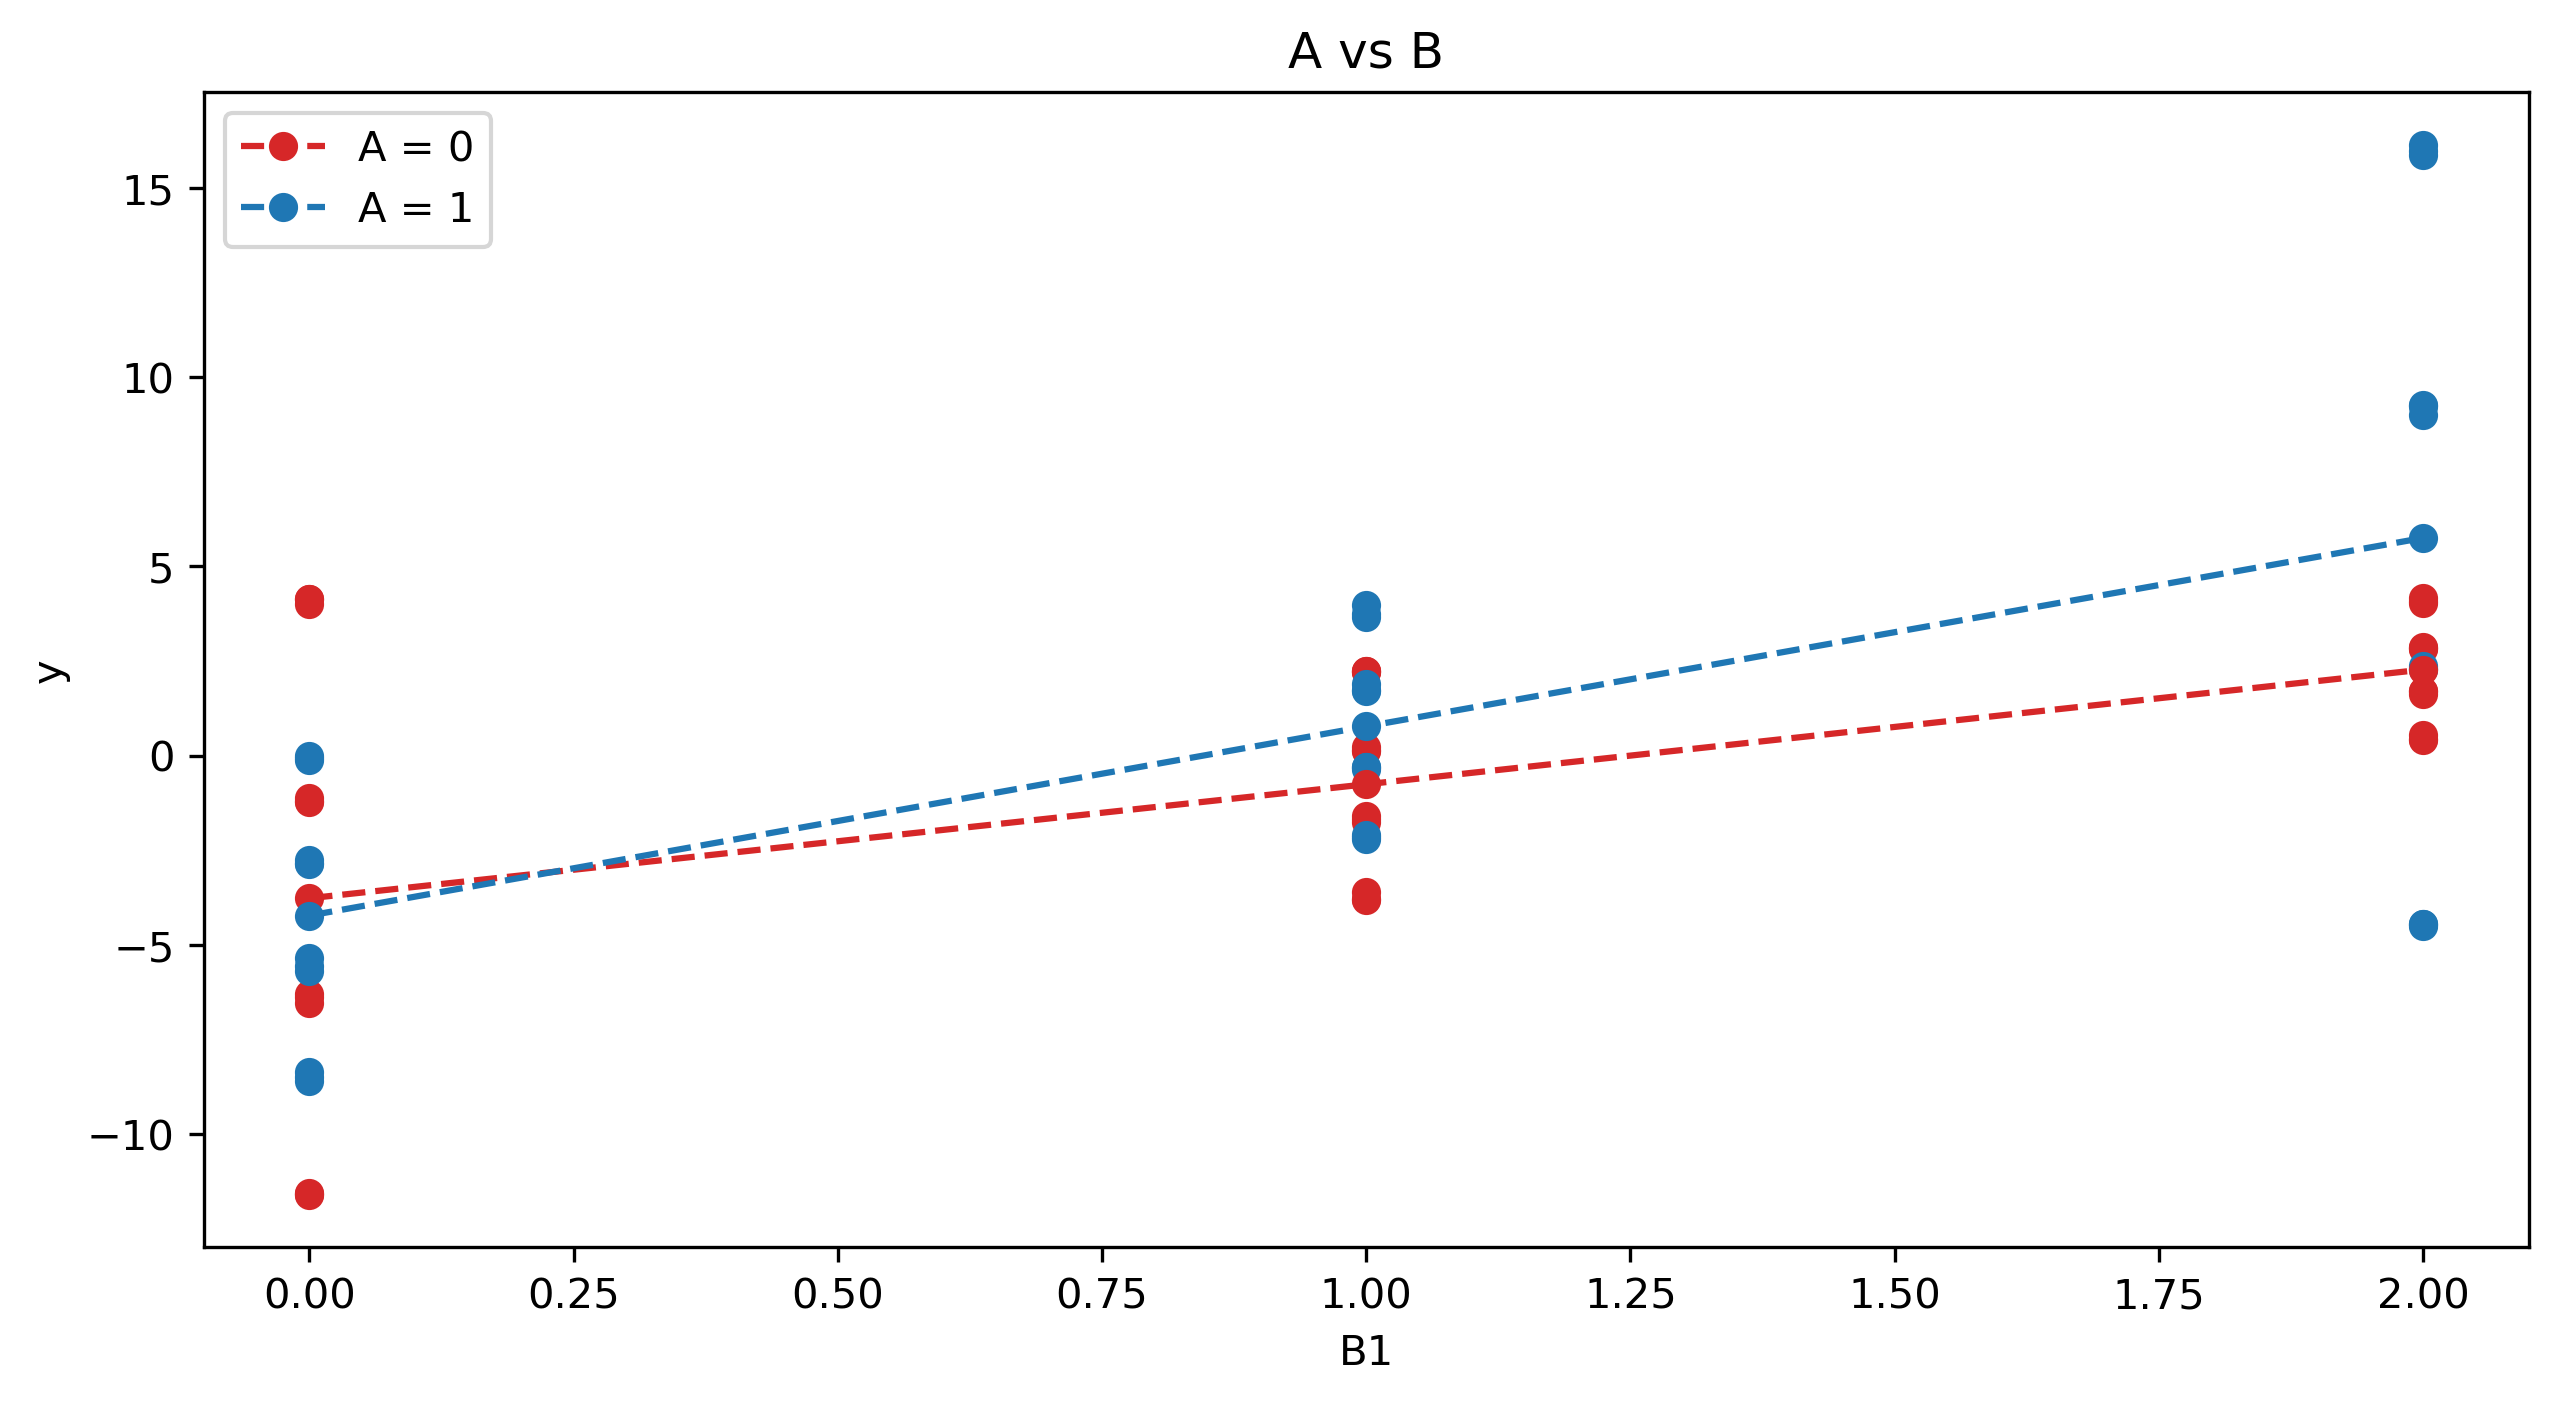

In [7]:
# df contiene los datos categóricos

# A con B
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi = 300)
a_color = {0 : 'tab:red', 1 : 'tab:blue'}

a_means = {0:[], 1:[]}
for a in df['A1'].unique():
    caso_A = df[df['A1'] == a]
    for b in df['B1'].unique():
        caso_AB = df[(df['A1'] == a) & (df['B1'] == b)]
        ax.scatter(caso_AB['B1'], caso_AB['y'], color = a_color[a])
        a_means[a].append(caso_AB['y'].mean())
        
for k in a_means.keys():
    ax.plot(df['B1'].unique(), a_means[k], color = a_color[k], marker='o', linestyle='--',
            label = f'A = {k}')

ax.set_xlabel('B1')
ax.set_ylabel('y')
ax.set_title('A vs B')
ax.legend()

Y podemos realizar el mismo procedimiento para la interacción entre otras variables.

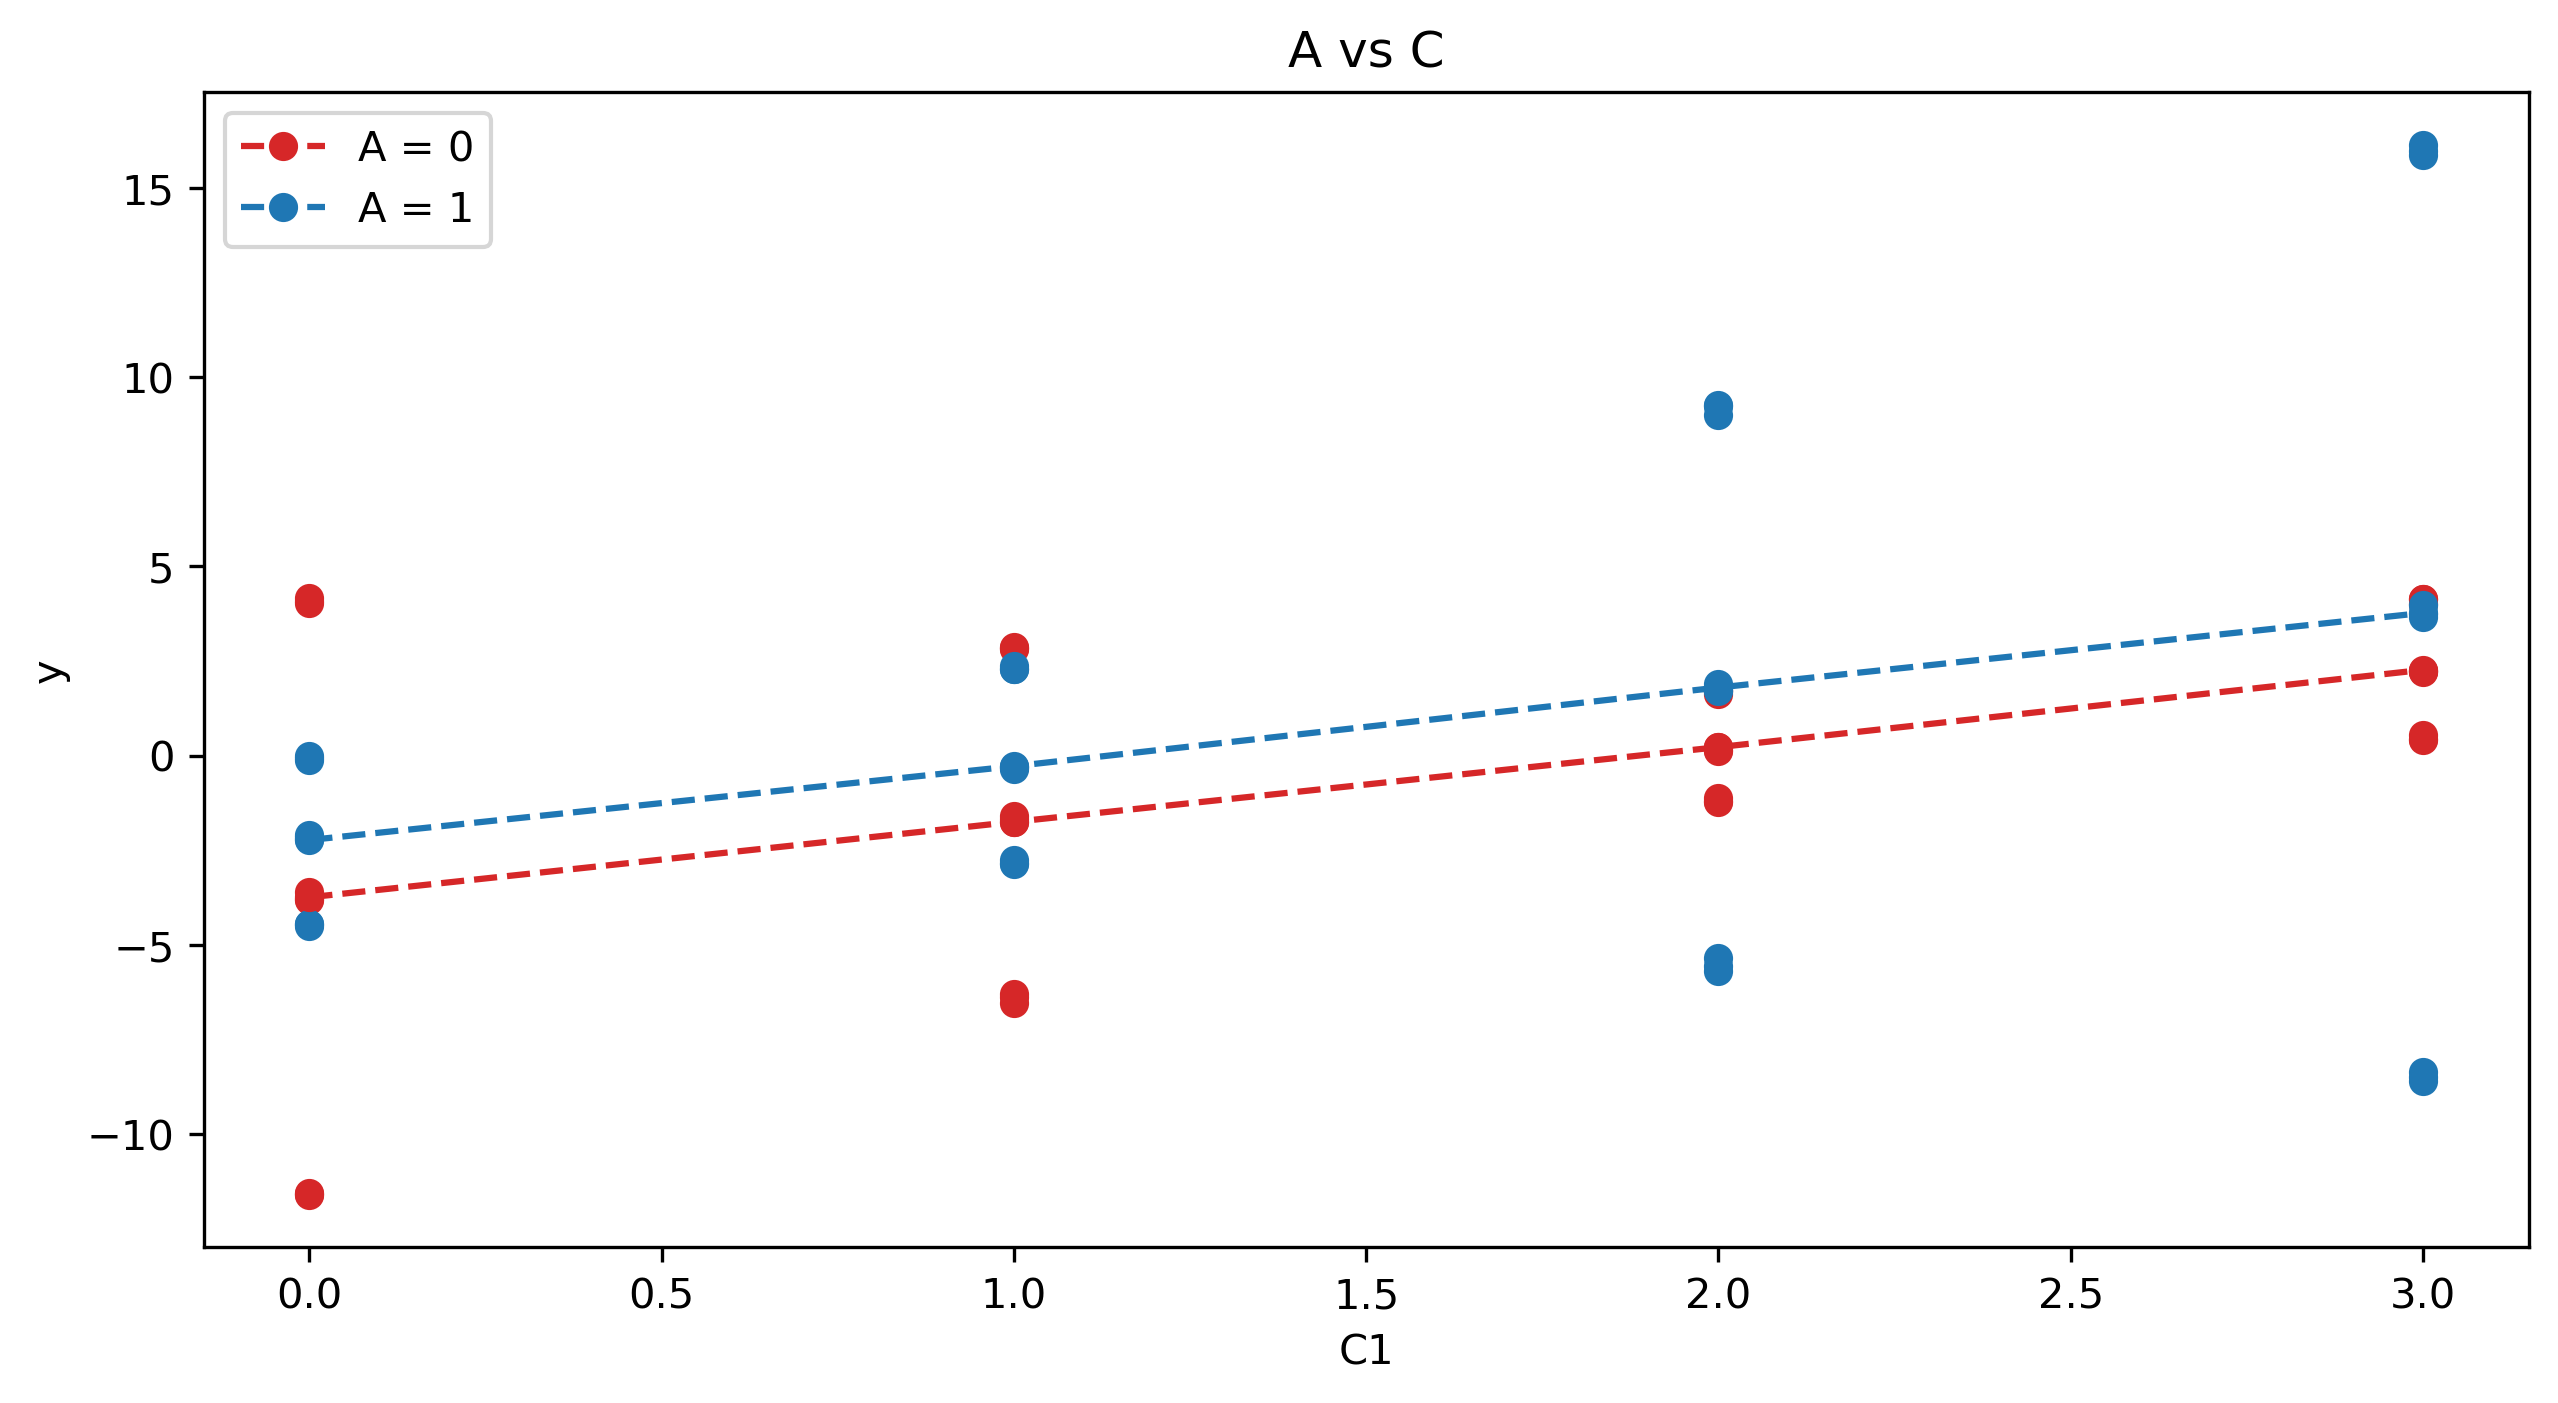

In [8]:
# df contiene los datos categóricos

# A con B
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi = 300)
a_color = {0 : 'tab:red', 1 : 'tab:blue'}

a_means = {0:[], 1:[]}
for a in df['A1'].unique():
    caso_A = df[df['A1'] == a]
    for c in df['C1'].unique():
        caso_AC = df[(df['A1'] == a) & (df['C1'] == c)]
        ax.scatter(caso_AC['C1'], caso_AC['y'], color = a_color[a])
        a_means[a].append(caso_AC['y'].mean())
        
for k in a_means.keys():
    ax.plot(df['C1'].unique(), a_means[k], color = a_color[k], marker='o', linestyle='--',
            label = f'A = {k}')

ax.set_xlabel('C1')
ax.set_ylabel('y')
ax.set_title('A vs C')
ax.legend()

Aunque, para facilidad de el gráfico es posible utilizar una función ya implementada en python.

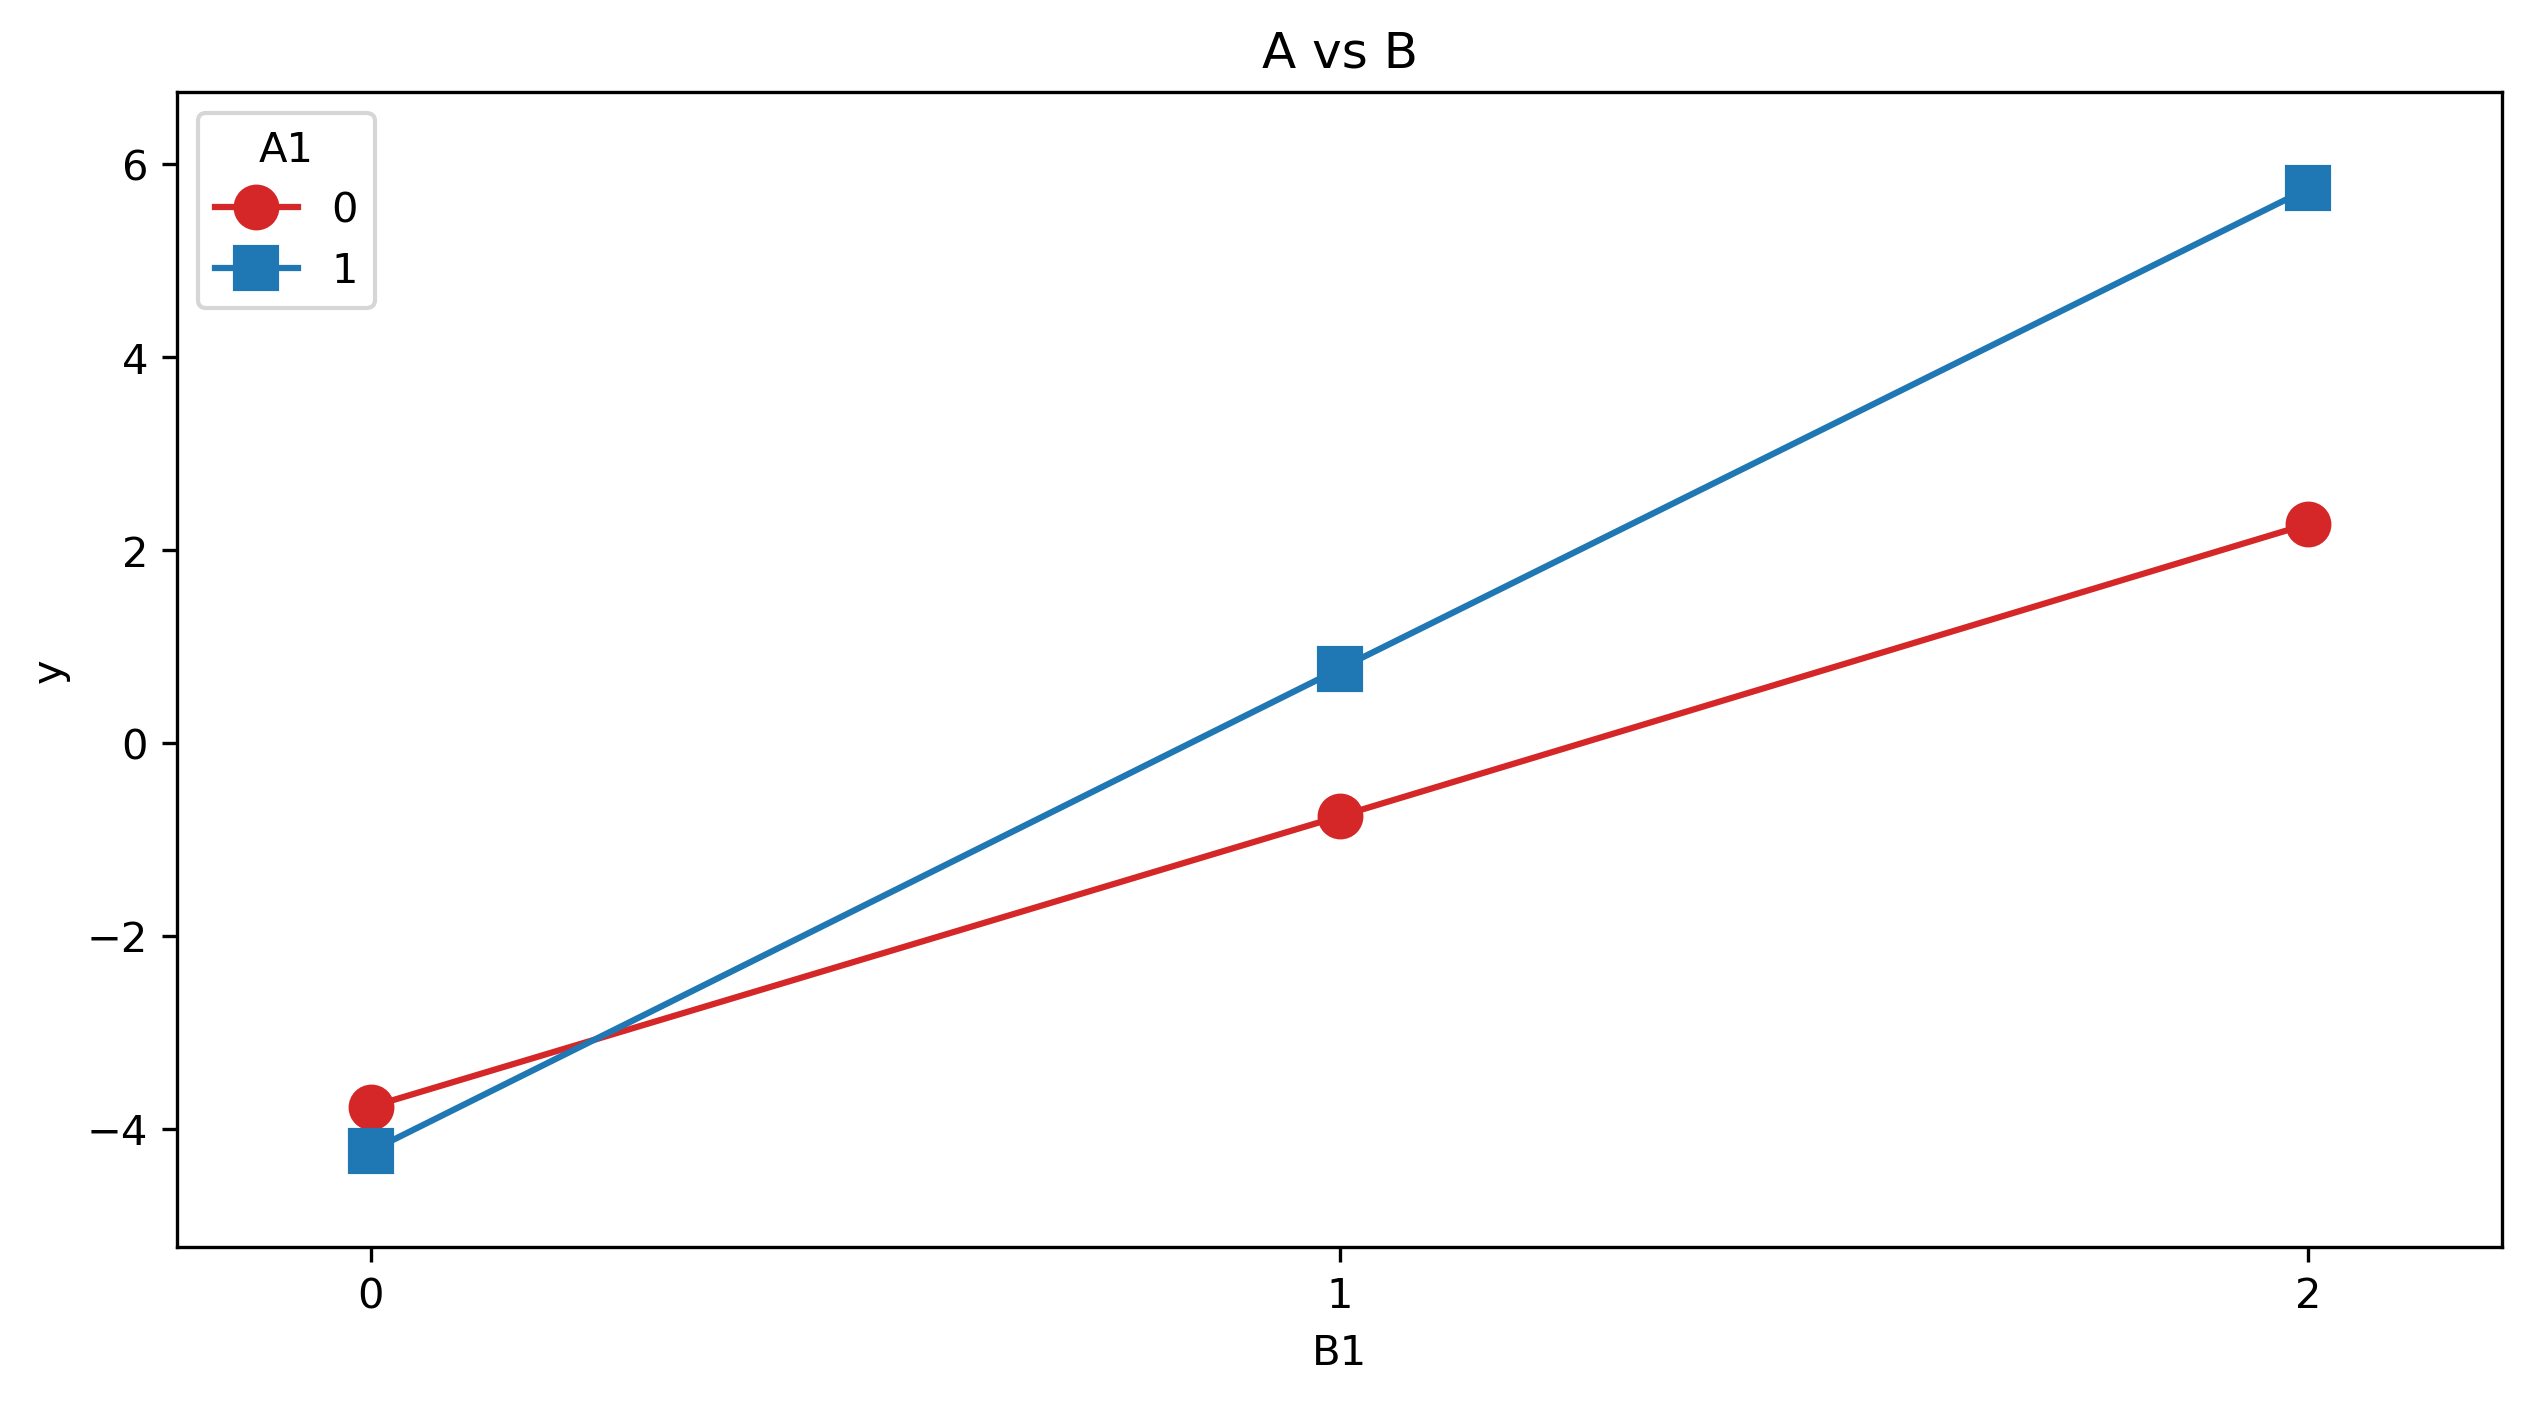

In [9]:
from statsmodels.graphics.factorplots import interaction_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi = 300)
interaction_plot(
    x = df['B1'],
    trace = df['A1'],
    response = df['y'],
    colors = ['tab:red', 'tab:blue'],
    markers = ['o', 's'],
    ms = 10,
    ax = ax
)
ax.set_xlabel('B1')
ax.set_ylabel('y')
ax.set_title('A vs B')
ax.set_xticks(df['B1'].unique())

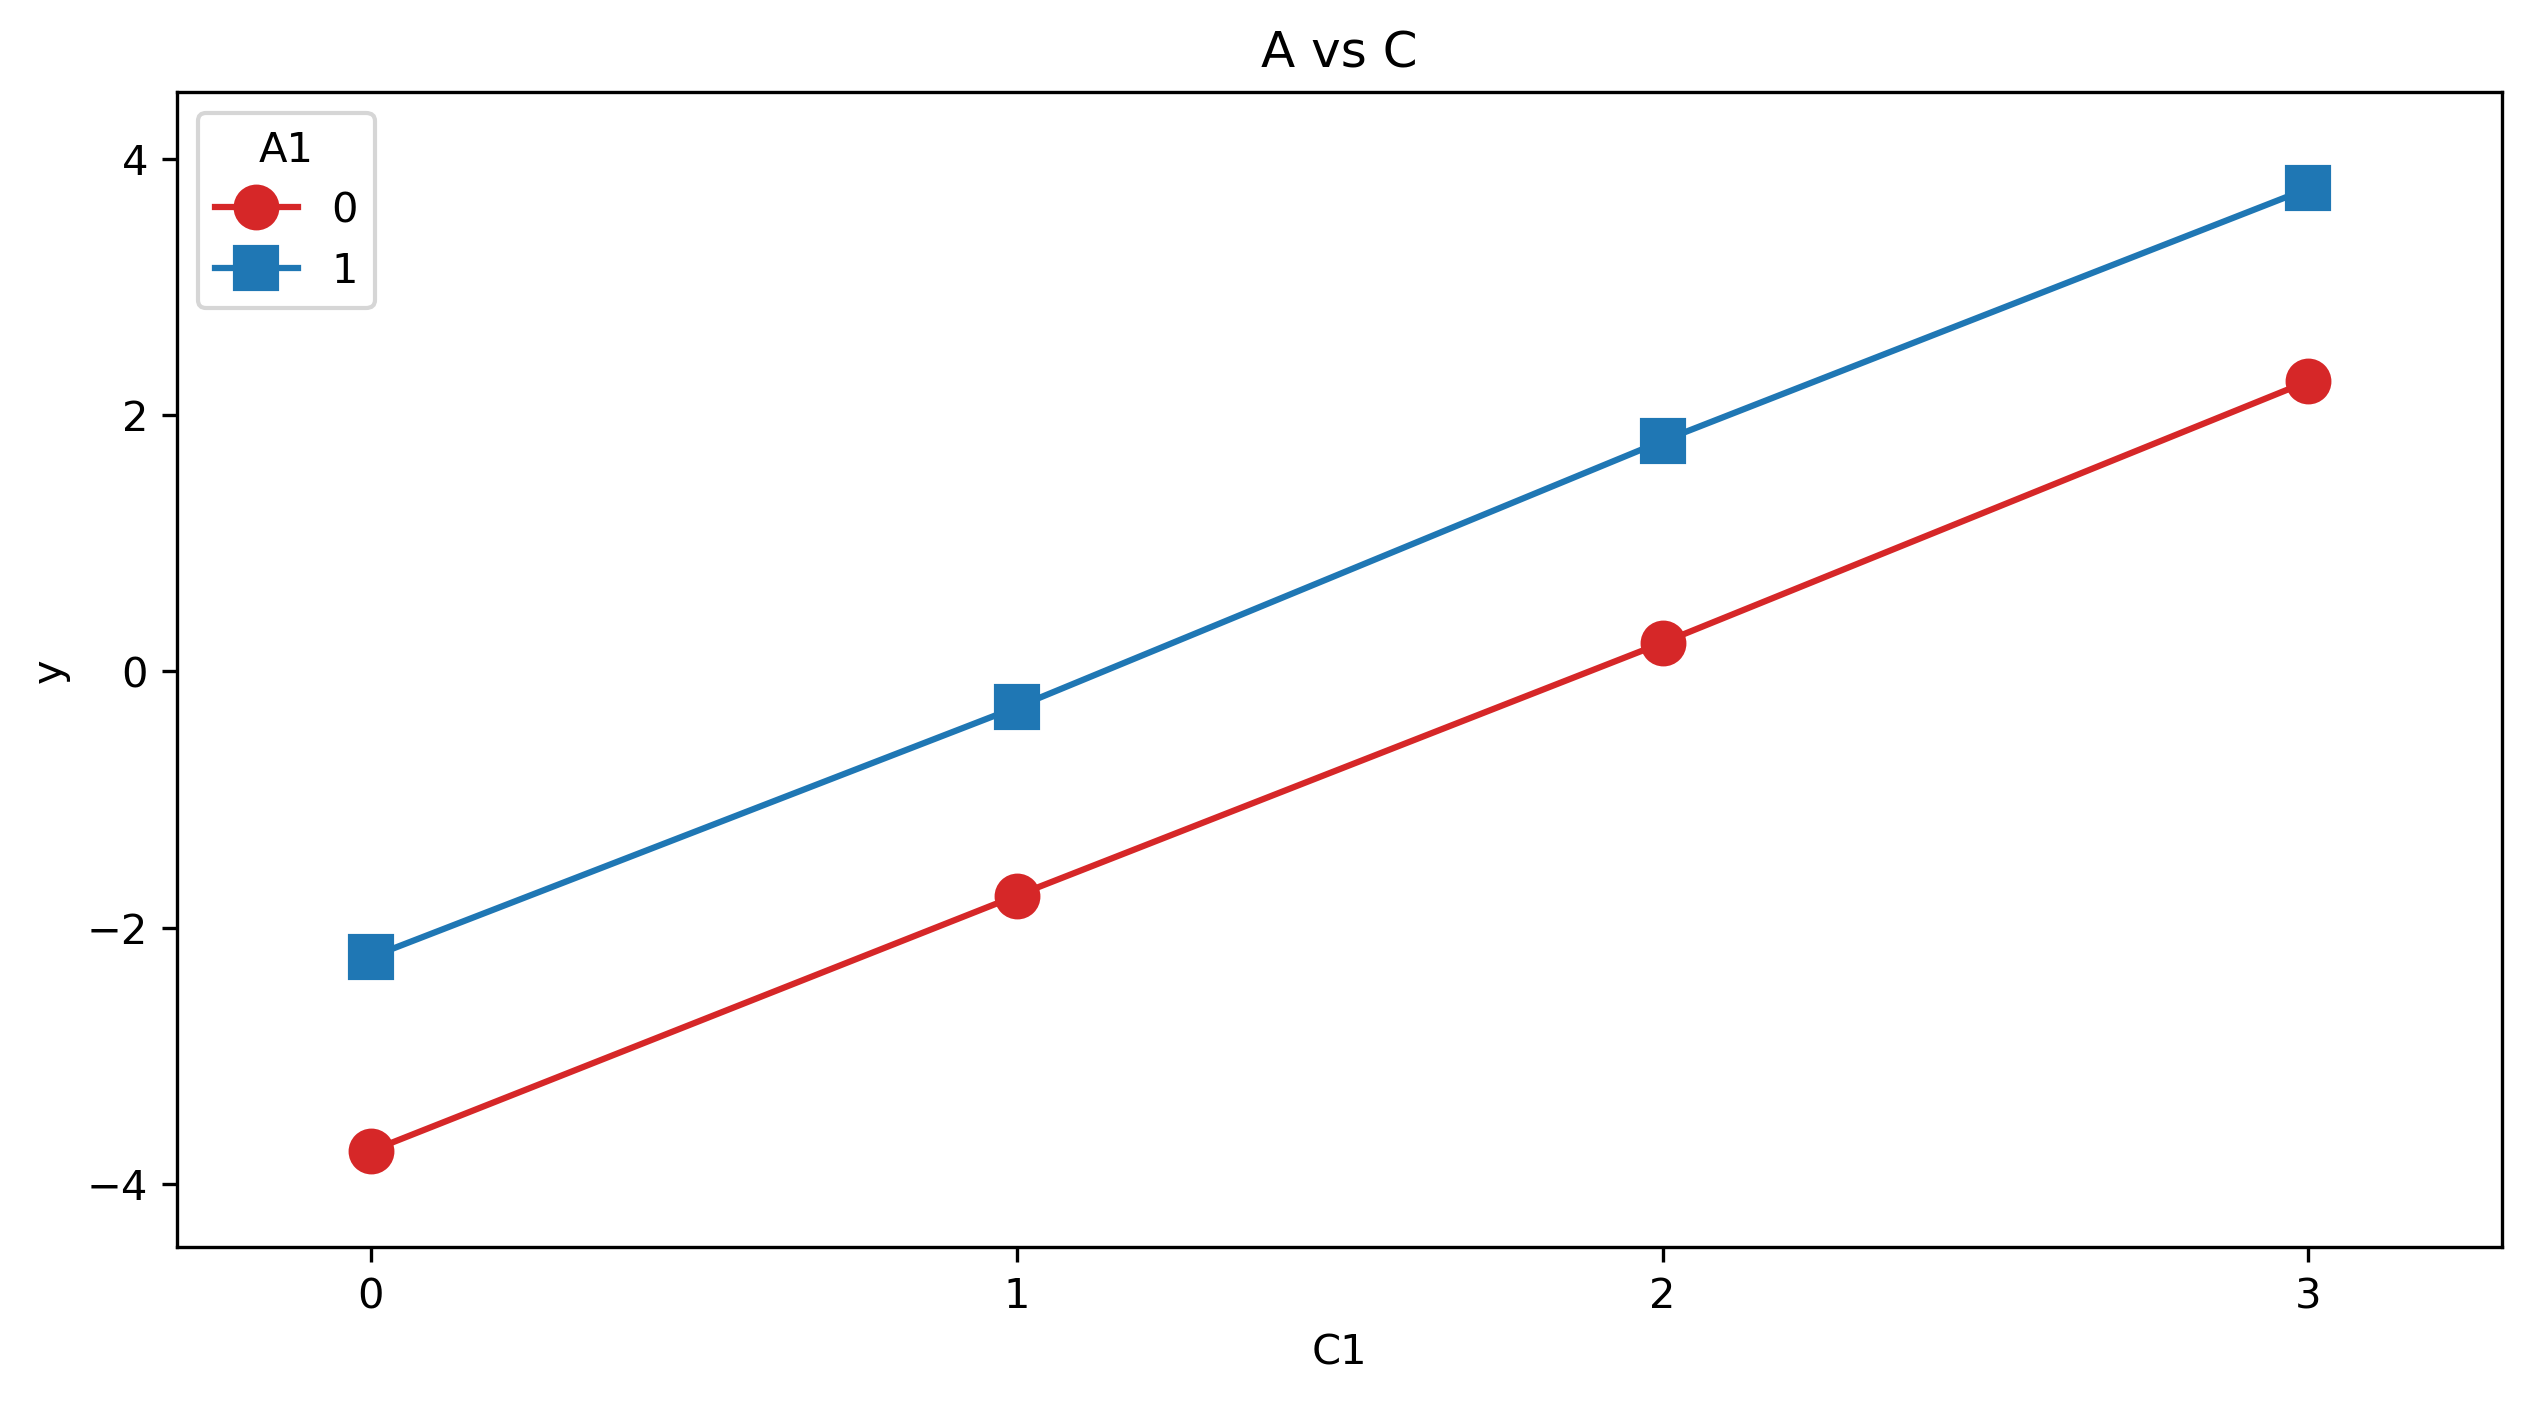

In [10]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi = 300)
interaction_plot(
    x = df['C1'],
    trace = df['A1'],
    response = df['y'],
    colors = ['tab:red', 'tab:blue'],
    markers = ['o', 's'],
    ms = 10,
    ax = ax
)
ax.set_xlabel('C1')
ax.set_ylabel('y')
ax.set_title('A vs C')
ax.set_xticks(df['C1'].unique())

## Analisis de Varianza
> Realice un analisis de varianza (ANOVA) sobre los datos generados. ¿Que concluye respecto a los efectos principales e interacciones? ¿Cual efecto resulta ser mas significativo? Recuerde verificar la normalidad de los residuos y su homocedasticidad.

El ANOVA factorial se ajusta via OLS con la formula de statsmodels:

```python
ols('y ~ C(A1) * C(B1) * C(C1)', data=df)
```

- `C(A1)`: declara `A1` como variable categorica (genera variables indicadoras internamente).
- `*`: expande a todos los efectos principales e interacciones (A + B + C + A:B + A:C + B:C + A:B:C).
- `typ=2`: cada efecto se calcula despues de ajustar todos los demas del mismo orden
  (suma de cuadrados tipo II, la convencional para disenos balanceados).

El estadistico $F = MS_{factor}/MS_E$ compara la varianza del tratamiento contra la varianza residual.
Un $F$ grande (p < 0.05) indica que el factor tiene efecto significativo sobre la respuesta.

In [11]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

ols_model = ols('y ~ C(A1) * C(B1) * C(C1)', data = df).fit() 
anova = anova_lm(ols_model, typ=2)
anova.round(5) # para que se vean mejor los p-values

,sum_sq,df,F,PR(>F)
C(A1),41.36822,1.0,5199.52488,0.00000
C(B1),769.69092,2.0,48370.78894,0.00000
C(C1),361.40256,3.0,15141.42559,0.00000
C(A1):C(B1),46.45465,2.0,2919.41633,0.00000
C(A1):C(C1),0.02578,3.0,1.07991,0.36655
C(B1):C(C1),38.37572,6.0,803.90020,0.00000
C(A1):C(B1):C(C1),965.91631,6.0,20234.15392,0.00000
Residual,0.38190,48.0,NaN,NaN


**Como leer la tabla ANOVA:**

| Fuente | F grande implica | Conclusion si p < 0.05 |
|--------|-----------------|------------------------|
| C(A1) | A tiene efecto sobre y | Factor A es significativo |
| C(B1) | B tiene efecto sobre y | Factor B es significativo |
| C(A1):C(B1) | el efecto de A depende del nivel de B | Interaccion A*B significativa |
| C(A1):C(B1):C(C1) | interaccion triple presente | Los tres factores interactuan |

El $F$ de A:B:C es alto, consistente con $w_{123} = 6$. El $F$ de A:C (~4) es el mas bajo, consistente con $w_{13} = 0.01$ (casi nulo).
El analisis estadistico recupera correctamente la estructura del modelo simulado.

Los supuestos del modelo ANOVA son los mismos que en regresion lineal: **normalidad** e
**independencia** de los errores, y **homocedasticidad** (varianza constante entre grupos).
Verificarlos es obligatorio antes de interpretar los p-values.

Cuatro diagnosticos en paralelo:
1. **Q-Q plot**: los residuos deben seguir la linea diagonal. Desviaciones en los extremos = colas pesadas.
2. **Residuos vs A, B, C**: los puntos deben dispersarse aleatoriamente alrededor de cero por cada nivel.
   Un patron en abanico indica heterocedasticidad.
3. **Shapiro-Wilk** (p-value en la leyenda del Q-Q): prueba formal de normalidad.
   Decision: p > 0.05 = no se rechaza normalidad.
4. **Levene** (p-value en el titulo de cada panel): prueba formal de igualdad de varianzas.
   Decision: p > 0.05 = varianzas iguales entre grupos.

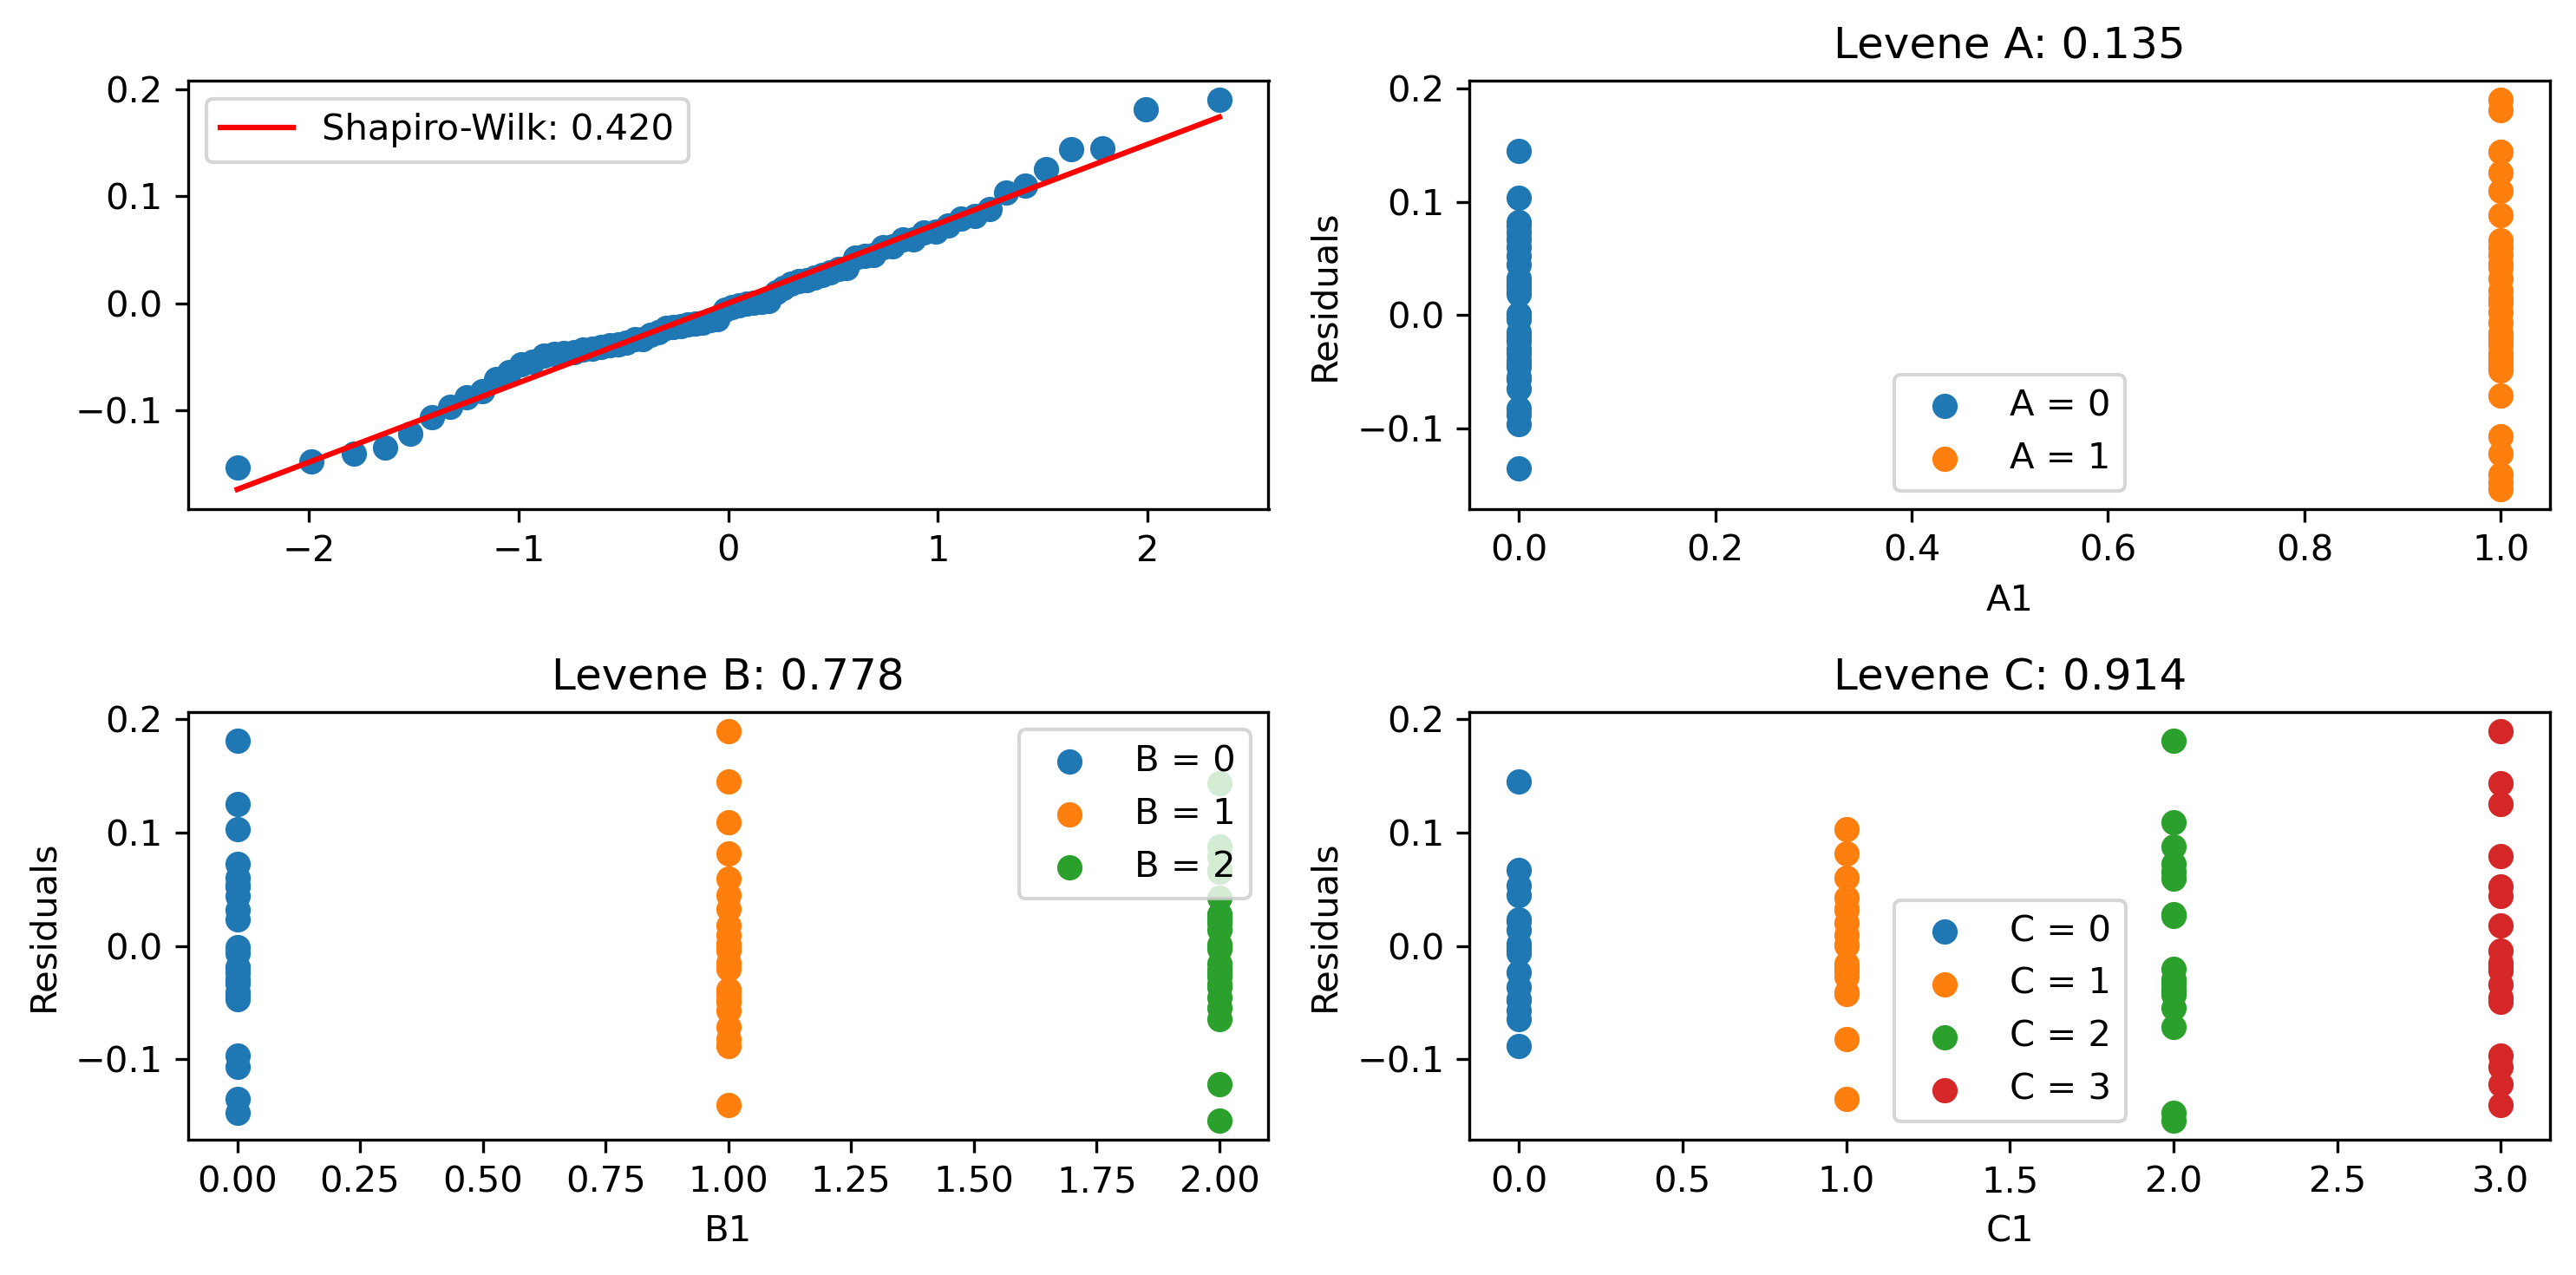

In [12]:
residuals = ols_model.resid
fig, ax = plt.subplots(2, 2, figsize=(10, 5), dpi = 300)
(osm, osr) , (slope, intercept, r) = stats.probplot(residuals, dist = "norm")
shapiro_wilk = stats.shapiro(residuals)[1]
ax[0,0].scatter(osm, osr)
ax[0,0].plot(osm, slope * osm + intercept, color = 'red', label = f'Shapiro-Wilk: {shapiro_wilk:.3f}')
ax[0,0].legend()
for i in df['A1'].unique():
    resid_a = residuals[df['A1'] == i]
    ax[0,1].scatter(i * np.ones(len(resid_a)), resid_a, label = f'A = {i}')
    
levene_A = stats.levene(residuals[df['A1'] == 0], residuals[df['A1'] == 1])[1]
ax[0,1].set_xlabel('A1')
ax[0,1].set_ylabel('Residuals')
ax[0,1].set_title('Residuals vs A')
ax[0,1].set_title(f'Levene A: {levene_A:.3f}')
ax[0,1].legend()

for i in df['B1'].unique():
    resid_b = residuals[df['B1'] == i]
    ax[1,0].scatter(i * np.ones(len(resid_b)), resid_b, label = f'B = {i}')
levene_B = stats.levene(residuals[df['B1'] == 0], residuals[df['B1'] == 1])[1]
ax[1,0].set_xlabel('B1')
ax[1,0].legend()
ax[1,0].set_ylabel('Residuals')
ax[1,0].set_title('Residuals vs B')
ax[1,0].set_title(f'Levene B: {levene_B:.3f}')
for i in df['C1'].unique():
    resid_c = residuals[df['C1'] == i]
    ax[1,1].scatter(i * np.ones(len(resid_c)), resid_c, label = f'C = {i}')
levene_C = stats.levene(residuals[df['C1'] == 0], residuals[df['C1'] == 1])[1]
ax[1,1].set_xlabel('C1')
ax[1,1].set_ylabel('Residuals')
ax[1,1].set_title('Residuals vs C')
ax[1,1].set_title(f'Levene C: {levene_C:.3f}')
ax[1,1].legend()


fig.tight_layout()

Recordemos que:
- **Shapiro-Wilk p > 0.05**: no se rechaza normalidad de los residuos — supuesto satisfecho.
- **Levene p > 0.05**: no se rechaza igualdad de varianzas entre grupos — supuesto satisfecho.

En este caso ambas pruebas son favorables, lo que da confianza en los p-values del ANOVA.
Si algun supuesto no se cumpliera, se podrian aplicar transformaciones a la respuesta (log, raiz cuadrada)
o recurrir a pruebas no parametricas (ver Parte 3).

## Estimación de Efectos

> Estime los efectos principales e interacciones. ¿Cuál variable o interacción posee el mayor efecto sobre la respuesta?

Al igual que como estudiamos los efectos de variables continuas a la hora de estimar un modelo lineal. Es posible realizar el mismo procedimiento para variables categóricas. Este tipo de modelos se denominan modelos de efecto fijo, debido a que cada condición posee un efecto fijo. 

Para poder estimar los efectos de los diferentes factores, es necesario aislar los efectos de los factores. 

Este tipo de modelos tienen la forma:
$$
y_{ijkl} = \mu + \tau_i + \beta_j + \gamma_k + (\tau \beta)_{ij} + (\tau \gamma)_{jk} + (\beta \gamma)_{ik} + (\tau \beta \gamma)_{ijk} + \epsilon_{ijkl}
$$

Para los casos de dos variables, estos se cálculan como:

$$
\widehat{\mu} = \mathbb{E}[y_{\cdot\cdot\cdot}]
$$
$$
\widehat{\tau}_i = \mathbb{E}[y_{i\cdot \cdot}] - \mathbb{E}[y_{\cdot\cdot\cdot}]
$$
$$
\widehat{\beta}_j = \mathbb{E}[y_{\cdot j \cdot}] - \mathbb{E}[y_{\cdot\cdot\cdot}]
$$
$$
\widehat{\left( \tau \beta \right)}_{ij} = \mathbb{E}[y_{i j \cdot }] - (\mathbb{E}[y_{i\cdot \cdot}] - \mathbb{E}[y_{\cdot\cdot\cdot}]) - (\mathbb{E}[y_{\cdot j \cdot}] - \mathbb{E}[y_{\cdot\cdot\cdot}]) - \mathbb{E}[y_{\cdot\cdot\cdot}]
$$
$$
\widehat{\left( \tau \beta \right)}_{ij} = \mathbb{E}[y_{i j \cdot }] - \mathbb{E}[y_{i\cdot \cdot}] - \mathbb{E}[y_{\cdot j \cdot}] + \mathbb{E}[y_{\cdot\cdot\cdot}]
$$

Y así, podemos generalizar para los otros casos al darnos cuenta que estámos aislando de forma sistemática el efecto de los diferentes factores. 

In [13]:
### Evaluemos

mu = df["y"].mean()

A_means = df.groupby("A1", observed=True)["y"].mean() # observed=True para que solo considere los niveles presentes en el dataset
B_means = df.groupby("B1", observed=True)["y"].mean()
C_means = df.groupby("C1", observed=True)["y"].mean()

AB_means = df.groupby(["A1", "B1"], observed= True)["y"].mean()
AC_means = df.groupby(["A1", "C1"], observed=True)["y"].mean()
BC_means = df.groupby(["B1", "C1"], observed=True)["y"].mean()

ABC_means = df.groupby(["A1", "B1", "C1"], observed=True)["y"].mean()

In [14]:
factor_A = A_means - mu
factor_B = B_means - mu   
factor_C = C_means - mu
interactions_AB = (
    AB_means
    - A_means
    - B_means
    + mu
)
interactions_AC = (
    AC_means
    - A_means
    - C_means
    + mu
)
interactions_BC = (
    BC_means
    - B_means
    - C_means
    + mu
)

interaction_3way = (
    ABC_means
    - AB_means.unstack().stack()
    - AC_means.unstack().stack()
    - BC_means.unstack().stack()
    + A_means
    + B_means
    + C_means
    - mu
)
print('Grand Mean')
display(mu)
print('Factor A')
display(factor_A)
print('Factor B')
display(factor_B)
print('Factor C')
display(factor_C)
print('Interaction AB')
display(interactions_AB)
print('Interaction AC')
display(interactions_AC)
print('Interaction BC')
display(interactions_BC)
print('Interaction ABC')
display(interaction_3way)


        

Grand Mean


np.float64(0.006884209950987991)

Factor A


A1
0   -0.757996
1    0.757996
Name: y, dtype: float64

Factor B


...

A1  C1
0   0     0.001448
    1     0.022615
    2    -0.029765
    3     0.005702
1   0    -0.001448
    1    -0.022615
    2     0.029765
    3    -0.005702
Name: y, dtype: float64

Interaction BC


B1  C1
0   0     1.171144
    1     0.398933
    2    -0.365053
    3    -1.205024
1   0     0.040180
    1     0.013025
    2    -0.045700
    3    -0.007504
2   0    -1.211323
    1    -0.411958
    2     0.410753
    3     1.212528
Name: y, dtype: float64

Interaction ABC


A1  B1  C1
0   0   0    -5.988268
1   0   0     5.988268
0   0   1    -2.043459
1   0   1     2.043459
0   0   2     1.979159
1   0   2    -1.979159
0   0   3     6.052569
1   0   3    -6.052569
0   1   0    -0.030589
1   1   0     0.030589
0   1   1     0.063031
1   1   1    -0.063031
0   1   2    -0.010746
1   1   2     0.010746
0   1   3    -0.021696
1   1   3     0.021696
0   2   0     6.018857
1   2   0    -6.018857
0   2   1     1.980428
1   2   1    -1.980428
0   2   2    -1.968413
1   2   2     1.968413
0   2   3    -6.030872
1   2   3     6.030872
dtype: float64

**Interpretacion de los efectos:**

Los efectos son desviaciones respecto a la gran media $\hat\mu \approx 0$.

| Fuente | Magnitud tipica | Recupera el peso real? |
|--------|----------------|------------------------|
| Factor A ($w_1 = 0.75$) | ~0.75 | Si: $A_1 - A_0 \approx 1.5 = 2 \times 0.75$ |
| Factor B ($w_2 = 4$) | ~4 por nivel | Si: rango de B es ~8 unidades |
| Factor C ($w_3 = 3$) | ~3 por nivel | Si |
| Interaccion A:B ($w_{12} = 1$) | ~3 | Si (amplificado por la escala) |
| Interaccion A:C ($w_{13} = 0.01$) | ~0.05 | Si: casi cero, como se esperaba |
| Interaccion A:B:C ($w_{123} = 6$) | ~8 | Si: el mayor efecto, como se esperaba |

Regla practica: cuanto mayor el valor absoluto del efecto, mayor la influencia de esa fuente
sobre la respuesta. Comparar efectos entre si (en lugar de contra cero) permite priorizar
factores en el rediseno del experimento.

# Parte 2: Diseño Factorial por Bloques

Suponga ahora que la variable $x_3$ representa una **variable de bloqueo**, es decir, una fuente sistemática de variabilidad no relacionada con los factores de interés. Se modela de la misma manera, pero con coeficientes distintos:

$$
    y = 1.5 + w_1x_1 + w_2x_2 + w_3x_3 + w_{1,2} x_1x_2 + w_{1,3} x_1x_3 + w_{2,3} x_2x_3  + w_{1,2,3}x_1x_2x_3
$$



In [15]:
matriz_diseno = fullfact([2,3,4])

matriz_diseno = pd.DataFrame(np.repeat(matriz_diseno, 3, axis=0), columns=['A1', 'B1', 'Bloque'])
matriz_diseno['Rep'] = np.tile(np.arange(1, 4), len(matriz_diseno) // 3)
matriz_diseno = matriz_diseno.astype('int').astype('category')

# pesos
weights = {
    "w1": 0.5,
    "w2": 4,
    "w3": 0.04,
    "w1_2": 3,
    "w1_3": 0.01,
    "w2_3": 0.09,
    "w1_2_3": 1
}

matriz_cont = matriz_diseno.copy()
matriz_cont = matriz_cont.apply(lambda x: minmax_scale(x, feature_range=(-1, 1))) 

y = (
    1.5 * matriz_cont['A1'] * weights['w1']
    + matriz_cont['B1'] * weights['w2']
    + matriz_cont['Bloque'] * weights['w3']
    + matriz_cont['A1'] * matriz_cont['B1'] * weights['w1_2']
    + matriz_cont['A1'] * matriz_cont['Bloque'] * weights['w1_3']
    + matriz_cont['B1'] * matriz_cont['Bloque'] * weights['w2_3']
    + matriz_cont['A1'] * matriz_cont['B1'] * matriz_cont['Bloque'] * weights['w1_2_3']
    + np.random.normal(0, 0.01, len(matriz_diseno))
)
matriz_diseno['y'] = y
matriz_cont['y'] = y

display(matriz_diseno)
display(matriz_cont)

,A1,B1,Bloque,Rep,y
0,0,0,0,1,-2.704013
1,0,0,0,2,-2.687256
2,0,0,0,3,-2.680332
3,1,0,0,1,-5.204663
4,1,0,0,2,-5.189197
...,...,...,...,...,...
67,0,2,3,2,-0.615956
68,0,2,3,3,-0.615984
69,1,2,3,1,8.874315
70,1,2,3,2,8.881717


,A1,B1,Bloque,Rep,y
0,-1.0,-1.0,-1.0,-1.0,-2.704013
1,-1.0,-1.0,-1.0,0.0,-2.687256
2,-1.0,-1.0,-1.0,1.0,-2.680332
3,1.0,-1.0,-1.0,-1.0,-5.204663
4,1.0,-1.0,-1.0,0.0,-5.189197
...,...,...,...,...,...
67,-1.0,1.0,1.0,0.0,-0.615956
68,-1.0,1.0,1.0,1.0,-0.615984
69,1.0,1.0,1.0,-1.0,8.874315
70,1.0,1.0,1.0,0.0,8.881717


## Análisis exploratorio

> A partir del nuevo modelo, grafique las curvas de respuesta entre $x_1$, $x_2$ y $y$. ¿Existe interacción entre $x_1$ y $x_2$?

En este caso, generamos curvas de respuesta por bloque.


In [16]:
surfaces = []

for i in matriz_diseno['Bloque'].unique():
    xi = np.linspace(-1, 1, 100)
    yi = np.linspace(-1, 1, 100)
    zi = 0

    xi, yi = np.meshgrid(xi, yi)
    response = (
        1.5 * xi * weights['w1']
        + yi * weights['w2']
        + i * weights['w3']
        + xi * yi * weights['w1_2']
        + xi * i * weights['w1_3']
        + yi * i * weights['w2_3']
        + xi * yi * i * weights['w1_2_3']
    )
    surfaces.append(go.Surface(x=xi, y=yi, z=response, name=f'Bloque {i}'))
fig = go.Figure(data=surfaces)
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='response'
    ),
    autosize=False,
    width=500,
    height=500,
    margin=dict(
        l=50,
        r=50,
        b=100,
        t=100,
        pad=4
    )
)
fig.update_traces(
    hoverinfo='none',
    showscale=False
)
fig.show()

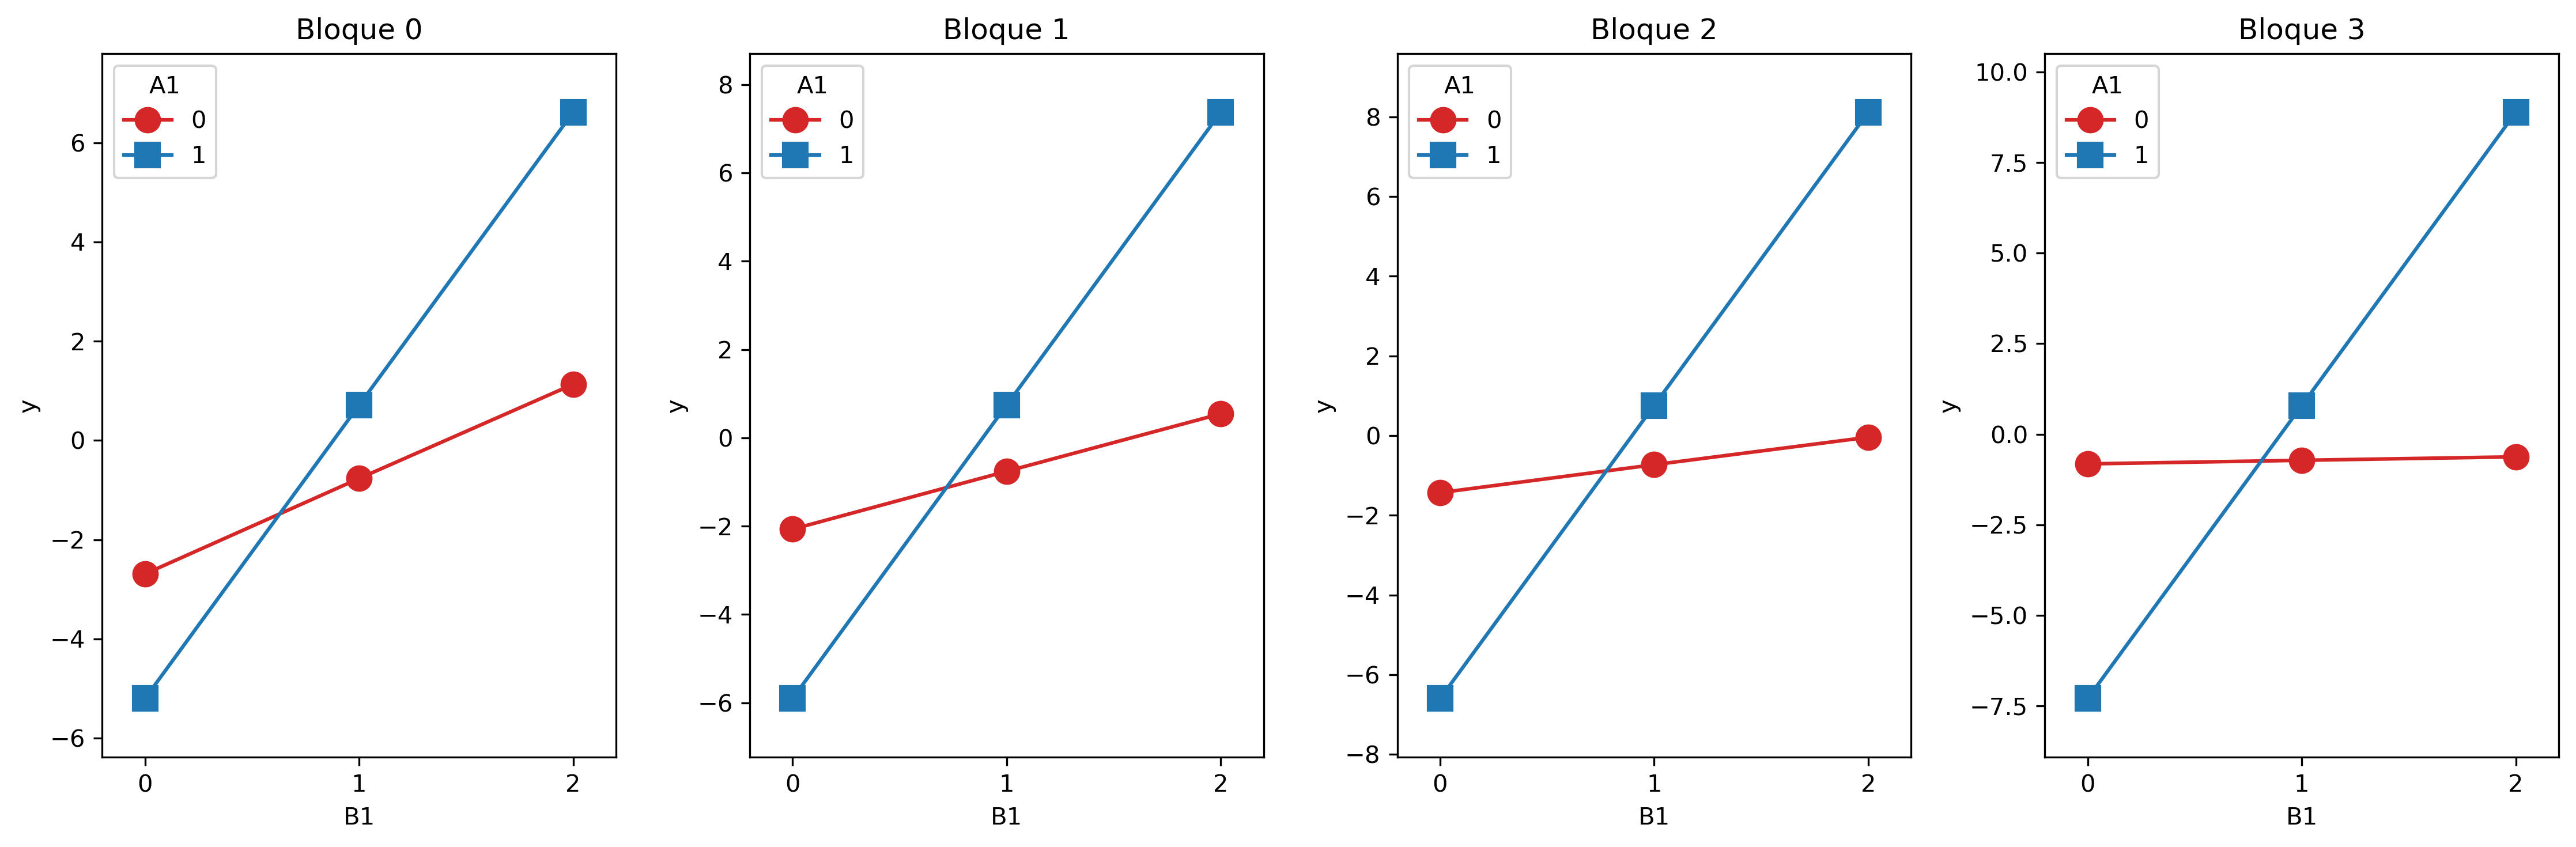

In [17]:
### interaction plot
fig, ax = plt.subplots(1, 4, figsize=(15, 5), dpi = 300)
for i in matriz_diseno['Bloque'].unique():
    x = matriz_diseno['B1'][matriz_diseno['Bloque'] == i].values
    trace = matriz_diseno['A1'][matriz_diseno['Bloque'] == i].values
    response = matriz_diseno['y'][matriz_diseno['Bloque'] == i]
    # print(trace)
    # print(x)
    interaction_plot(
        x = x,
        trace = trace,
        response = response,
        colors = ['tab:red', 'tab:blue'],
        markers = ['o', 's'],
        ms = 10,
        ax = ax[i]
    )
    ax[i].set_xlabel('B1')
    ax[i].set_ylabel('y')
    ax[i].set_title(f'Bloque {i}')
    ax[i].set_xticks(matriz_diseno['B1'].unique())
    ax[i].set_xticklabels(matriz_diseno['B1'].unique())
    ax[i].legend(title='A1', loc='upper left')
fig.tight_layout()
plt.show()

## ANOVA por bloques

> Realice un nuevo análisis de varianza. ¿Cuál es el efecto del bloque $x_3$ sobre la respuesta? ¿Cómo afecta la varianza del modelo?

Consideremos el caso sin replicaciones.

In [18]:
rep1 = matriz_diseno[matriz_diseno['Rep'] == 1].drop(columns=['Rep'])

In [ ]:
def anova_2f_block(df, var1=None, var2=None, y=None, block=None):
    """
    ANOVA de dos factores con diseno en bloques completos aleatorizados (RCBD).

    Implementa las formulas de suma de cuadrados de Montgomery (2017), Cap. 5.6.
    Requiere una sola replicacion por celda (sin repeticiones dentro del bloque).

    Parametros
    ----------
    df    : DataFrame con los datos (sin la columna Rep).
    var1  : str, nombre del primer factor (columna categorica).
    var2  : str, nombre del segundo factor (columna categorica).
    y     : str, nombre de la variable respuesta.
    block : str, nombre de la variable de bloqueo (columna categorica).

    Retorna
    -------
    DataFrame con columnas [Source, SS, df, MS, F, p-value].
    El bloque y el error no tienen F ni p-value (el bloque absorbe variabilidad, no se prueba).

    Formulas (Montgomery, 2017, Sec. 5.6)
    ------
    CF = (sum y)^2 / (a*b*n)                          # factor de correccion
    SS_A  = (1/(b*n)) * sum(sum_A_i^2) - CF
    SS_B  = (1/(a*n)) * sum(sum_B_j^2) - CF
    SS_AB = (1/n) * sum(sum_AB_ij^2) - CF - SS_A - SS_B
    SS_block = (1/(a*b)) * sum(sum_block_k^2) - CF
    SS_E = SS_T - SS_A - SS_B - SS_AB - SS_block
    df_error = (a*b - 1)*(n - 1)
    """
    if var1 is None or var2 is None or y is None or block is None:
        raise ValueError("var1, var2, y and block must be defined")

    grand_sum = df[y].sum()

    sum_A      = df.groupby(var1)[y].sum()
    sum_B      = df.groupby(var2)[y].sum()
    sum_AB     = df.groupby([var1, var2])[y].sum()
    sum_blocks = df.groupby(block)[y].sum()

    a = len(df[var1].unique())
    b = len(df[var2].unique())
    n = len(df[block].unique())

    mean_sum_sq = grand_sum**2 / (a * b * n)

    sum_of_squares_A     = (1 / (b * n)) * (sum_A**2).sum() - mean_sum_sq
    sum_of_squares_B     = (1 / (a * n)) * (sum_B**2).sum() - mean_sum_sq
    sum_subtotals        = (1 / n) * (sum_AB**2).sum() - mean_sum_sq
    sum_of_squares_AB    = sum_subtotals - sum_of_squares_A - sum_of_squares_B
    sum_of_squares_block = (1 / (a * b)) * (sum_blocks**2).sum() - mean_sum_sq
    sum_of_squares_total = np.sum(df[y] ** 2) - mean_sum_sq
    sum_of_squares_error = (sum_of_squares_total - sum_of_squares_A
                            - sum_of_squares_B - sum_of_squares_AB
                            - sum_of_squares_block)

    df_A     = a - 1
    df_B     = b - 1
    df_AB    = (a - 1) * (b - 1)
    df_block = n - 1
    df_total = len(df) - 1
    df_error = (a * b - 1) * (n - 1)

    MS_A     = sum_of_squares_A / df_A
    MS_B     = sum_of_squares_B / df_B
    MS_AB    = sum_of_squares_AB / df_AB
    MS_block = sum_of_squares_block / df_block
    MS_error = sum_of_squares_error / df_error
    MS_T     = sum_of_squares_total / df_total

    F_A  = MS_A / MS_error
    F_B  = MS_B / MS_error
    F_AB = MS_AB / MS_error

    p_val_A  = stats.f.sf(F_A,  df_A,  df_error)
    p_val_B  = stats.f.sf(F_B,  df_B,  df_error)
    p_val_AB = stats.f.sf(F_AB, df_AB, df_error)

    rows = [
        [var1, sum_of_squares_A, df_A,     MS_A,     F_A,  p_val_A],
        [var2, sum_of_squares_B,     df_B,     MS_B,     F_B,  p_val_B],
        [f"{var1}*{var2}", sum_of_squares_AB, df_AB,    MS_AB,    F_AB, p_val_AB],
        [block,         sum_of_squares_block, df_block, MS_block, "-",  "-"],
        ["Error",       sum_of_squares_error, df_error, MS_error, "-",  "-"],
        ["Total",       sum_of_squares_total, df_total, MS_T,     "-",  "-"],
    ]
    results = pd.DataFrame(rows, columns=["Source", "SS", "df", "MS", "F", "p-value"])
    return results.round(5)

In [20]:
anova_2f_block(rep1, var1 = 'A1', var2 = 'B1', y = 'y', block = 'Bloque')

,Source,SS,df,MS,F,p-value
0,A1,13.53975,1,13.53975,22.750571,0.000248
1,B1,256.00166,2,128.00083,215.077187,0.0
2,A1*B1,143.75060,2,71.87530,120.770603,0.0
3,Bloque,0.01813,3,0.00604,-,-
4,Error,8.92709,15,0.59514,-,-
5,Total,422.23723,23,18.35814,-,-


# Parte 3: Análsis estadístico clásico

> Visualice la curva de respuesta con el nuevo modelo reducido (sin $x_3$). Comente cualquier cambio observado.

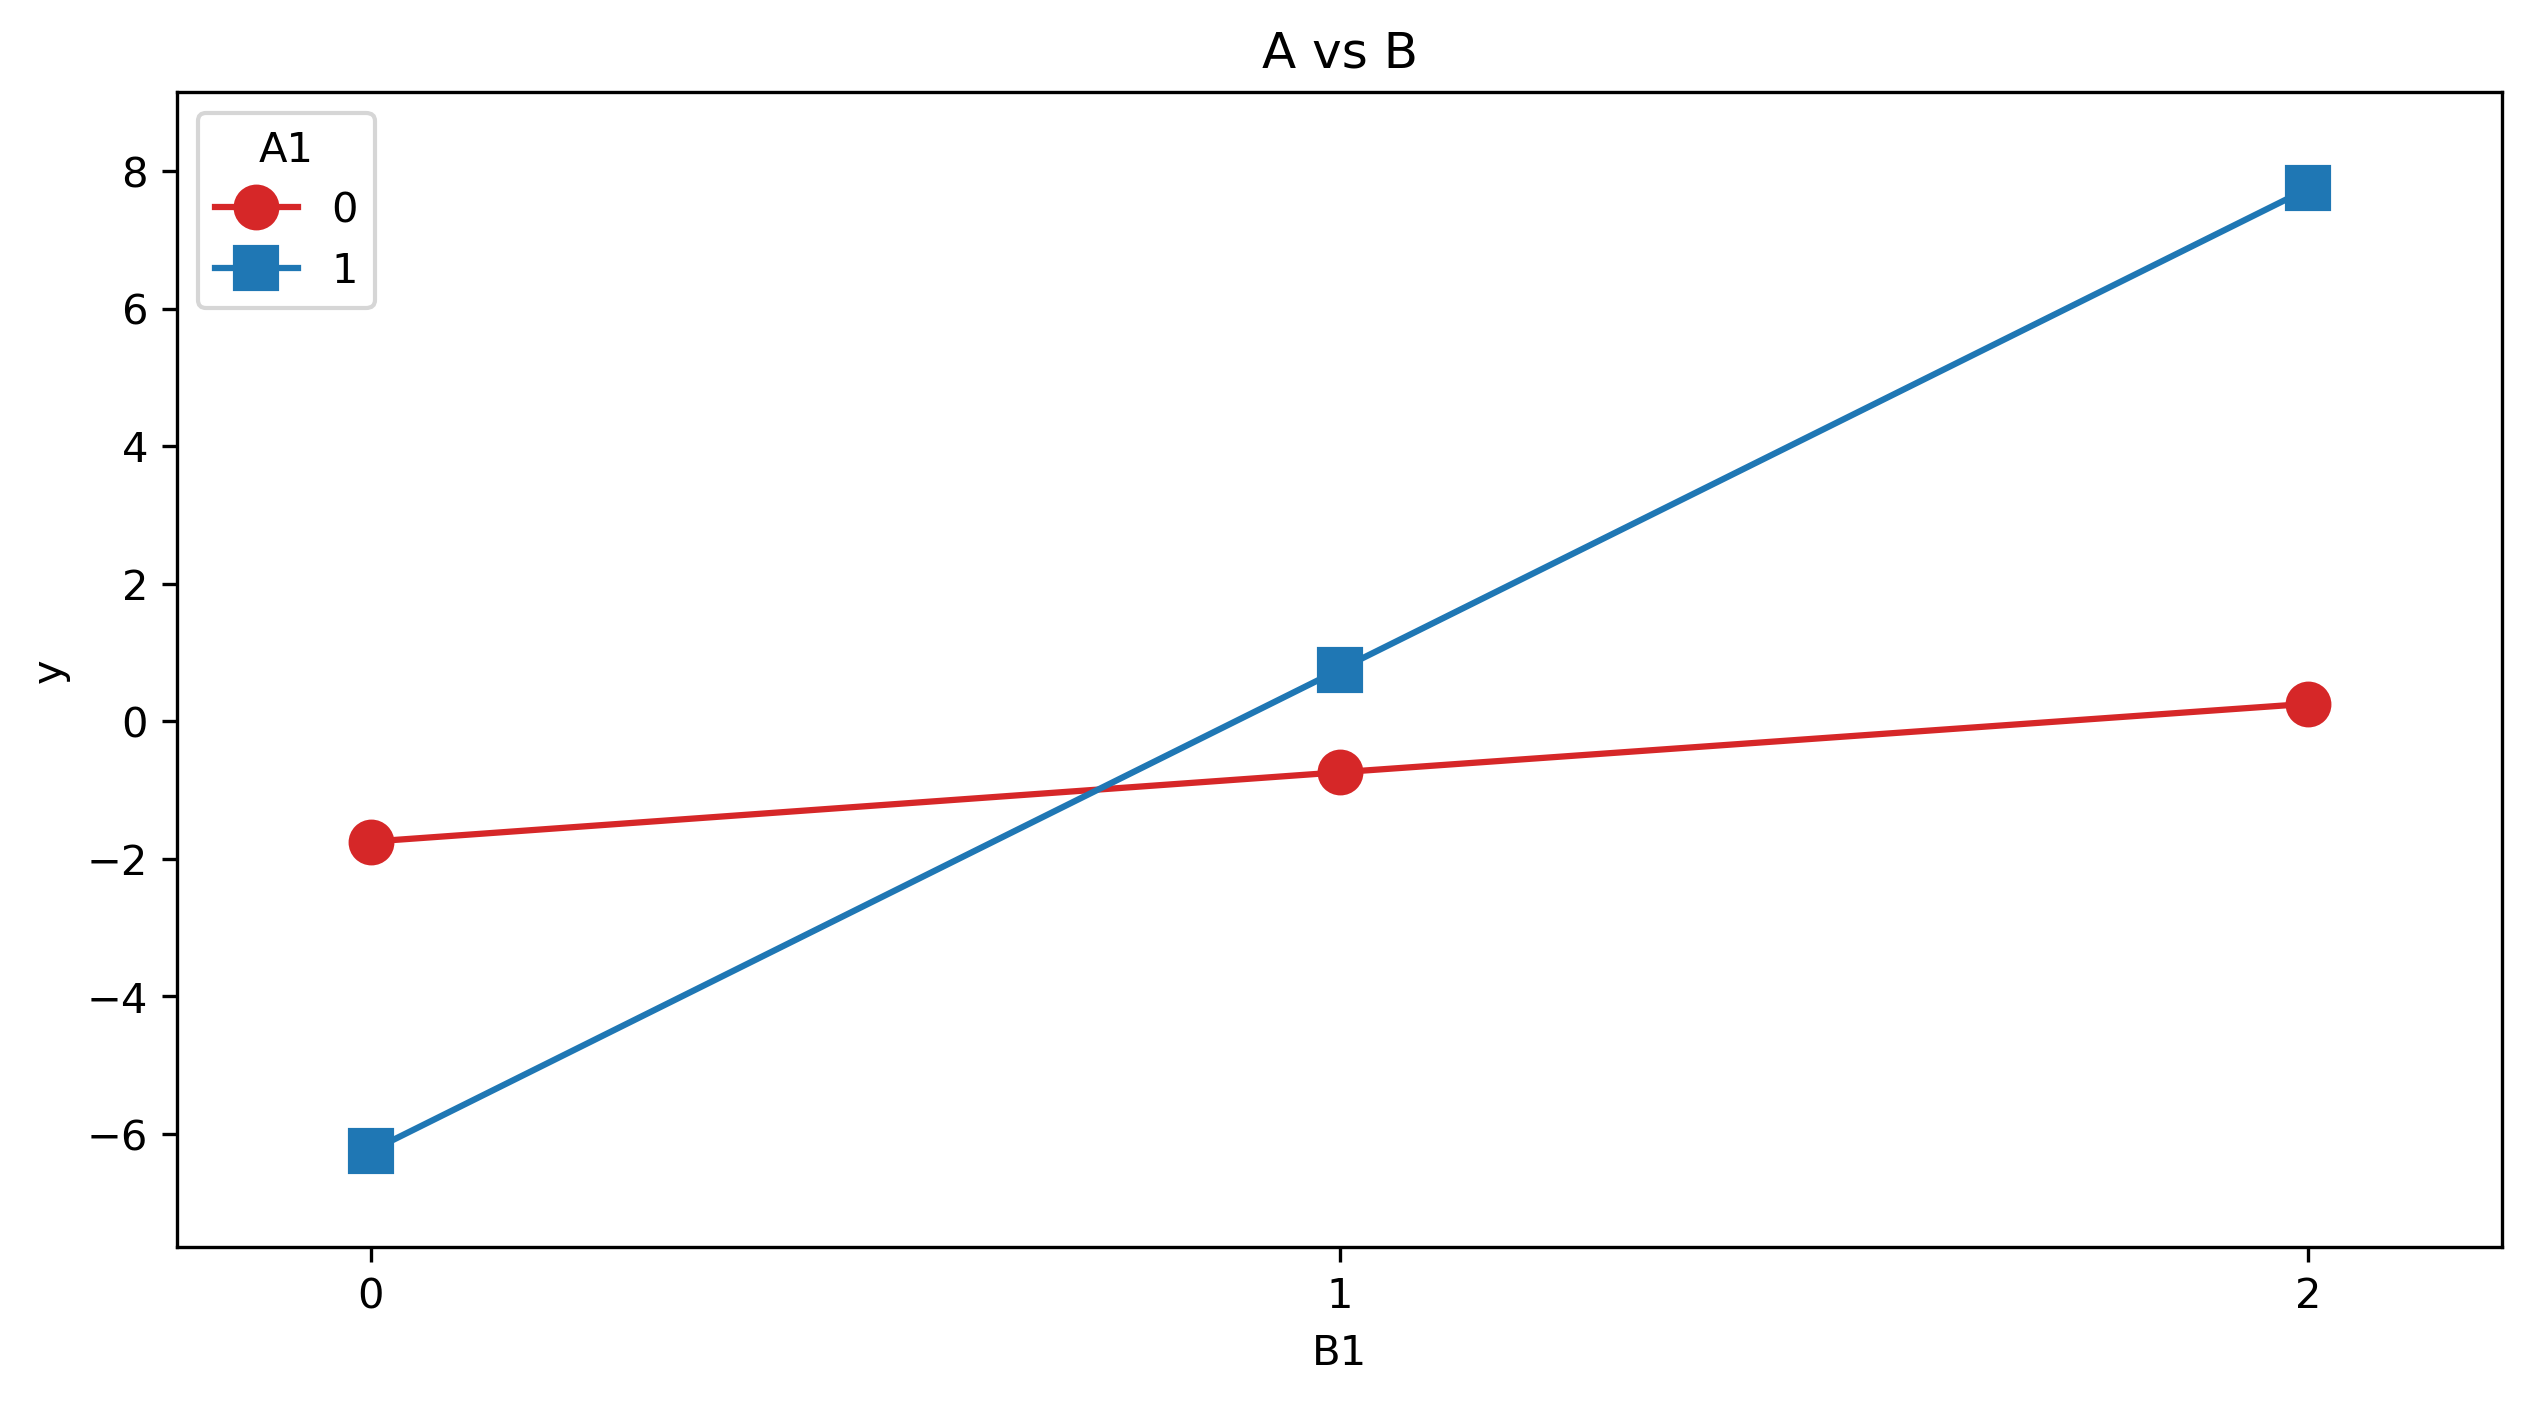

In [21]:
# dropeamos la variable x3

matriz_diseno_3 = matriz_diseno.copy()
matriz_diseno_3 = matriz_diseno_3.drop(columns=['Bloque', 'Rep']) # hay 12 replicas

# interaction plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi = 300)
interaction_plot(
    x = matriz_diseno_3['B1'],
    trace = matriz_diseno_3['A1'],
    response = matriz_diseno_3['y'],
    colors = ['tab:red', 'tab:blue'],
    markers = ['o', 's'],
    ms = 10,
    ax = ax
)
ax.set_xlabel('B1')
ax.set_ylabel('y')
ax.set_title('A vs B')
ax.set_xticks(matriz_diseno_3['B1'].unique())


> Realice un análisis de varianza sobre el modelo sin bloqueo. 


In [22]:
ols_model_3 = ols('y ~ A1 * B1', data = matriz_diseno_3).fit()
anova_3 = anova_lm(ols_model_3, typ=2)
anova_3.round(10) # para que se vean mejor los p-values

,sum_sq,df,F,PR(>F)
A1,40.350438,1.0,99.094354,0.0
B1,768.484433,2.0,943.638695,0.0
A1:B1,431.560568,2.0,529.922577,0.0
Residual,26.874678,66.0,NaN,NaN


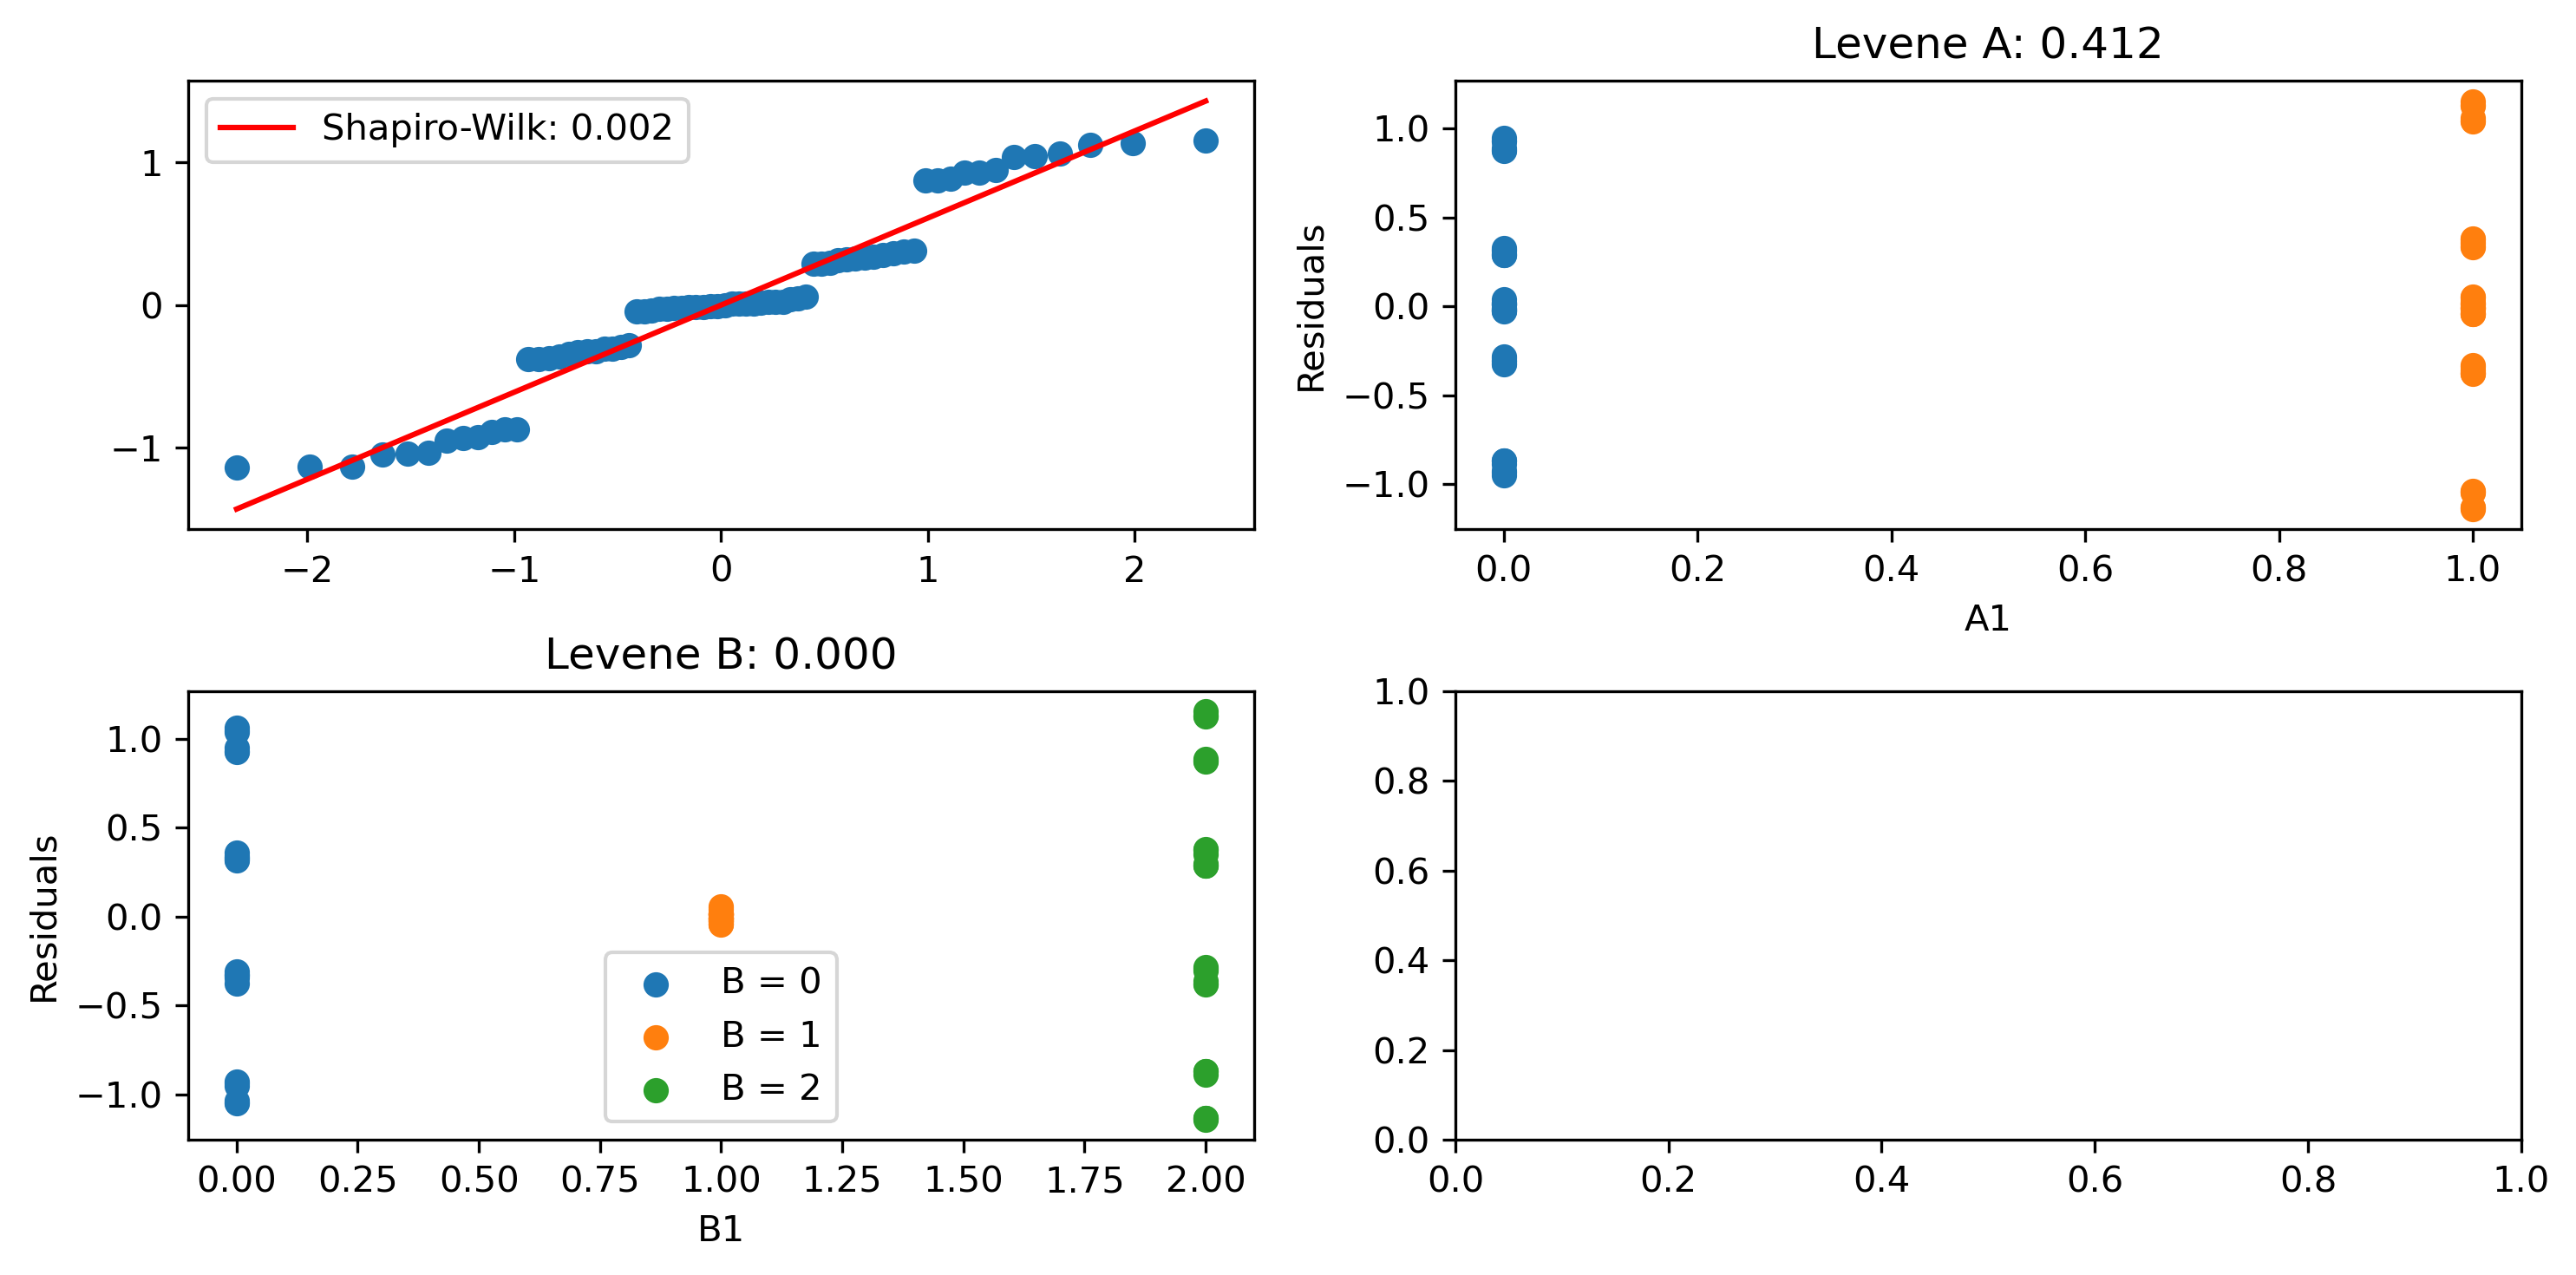

In [23]:
resid = ols_model_3.resid
fig, ax = plt.subplots(2, 2, figsize=(10, 5), dpi = 300)
(osm, osr) , (slope, intercept, r) = stats.probplot(resid, dist = "norm")
shapiro_wilk = stats.shapiro(resid)[1]
ax[0,0].scatter(osm, osr)
ax[0,0].plot(osm, slope * osm + intercept, color = 'red', label = f'Shapiro-Wilk: {shapiro_wilk:.3f}')
ax[0,0].legend()
for i in matriz_diseno_3['A1'].unique():
    resid_a = resid[matriz_diseno_3['A1'] == i]
    ax[0,1].scatter(i * np.ones(len(resid_a)), resid_a, label = f'A = {i}')
levene_A = stats.levene(resid[matriz_diseno_3['A1'] == 0], resid[matriz_diseno_3['A1'] == 1])[1]
ax[0,1].set_xlabel('A1')
ax[0,1].set_ylabel('Residuals')
ax[0,1].set_title('Residuals vs A')
ax[0,1].set_title(f'Levene A: {levene_A:.3f}')
for i in matriz_diseno_3['B1'].unique():
    resid_b = resid[matriz_diseno_3['B1'] == i]
    ax[1,0].scatter(i * np.ones(len(resid_b)), resid_b, label = f'B = {i}')
levene_B = stats.levene(resid[matriz_diseno_3['B1'] == 0], resid[matriz_diseno_3['B1'] == 1])[1]
ax[1,0].set_xlabel('B1')
ax[1,0].legend()
ax[1,0].set_ylabel('Residuals')
ax[1,0].set_title('Residuals vs B')
ax[1,0].set_title(f'Levene B: {levene_B:.3f}')
fig.tight_layout()


## Test Clásicos

> Agrupe los datos por la variable $x_1$. ¿Cuál grupo presenta un mayor promedio en $y$? Genere una comparación estadística (por ejemplo, prueba t o ANOVA de un factor) y reporte su significancia.


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_14988/2661832554.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='A1', loc='upper left')


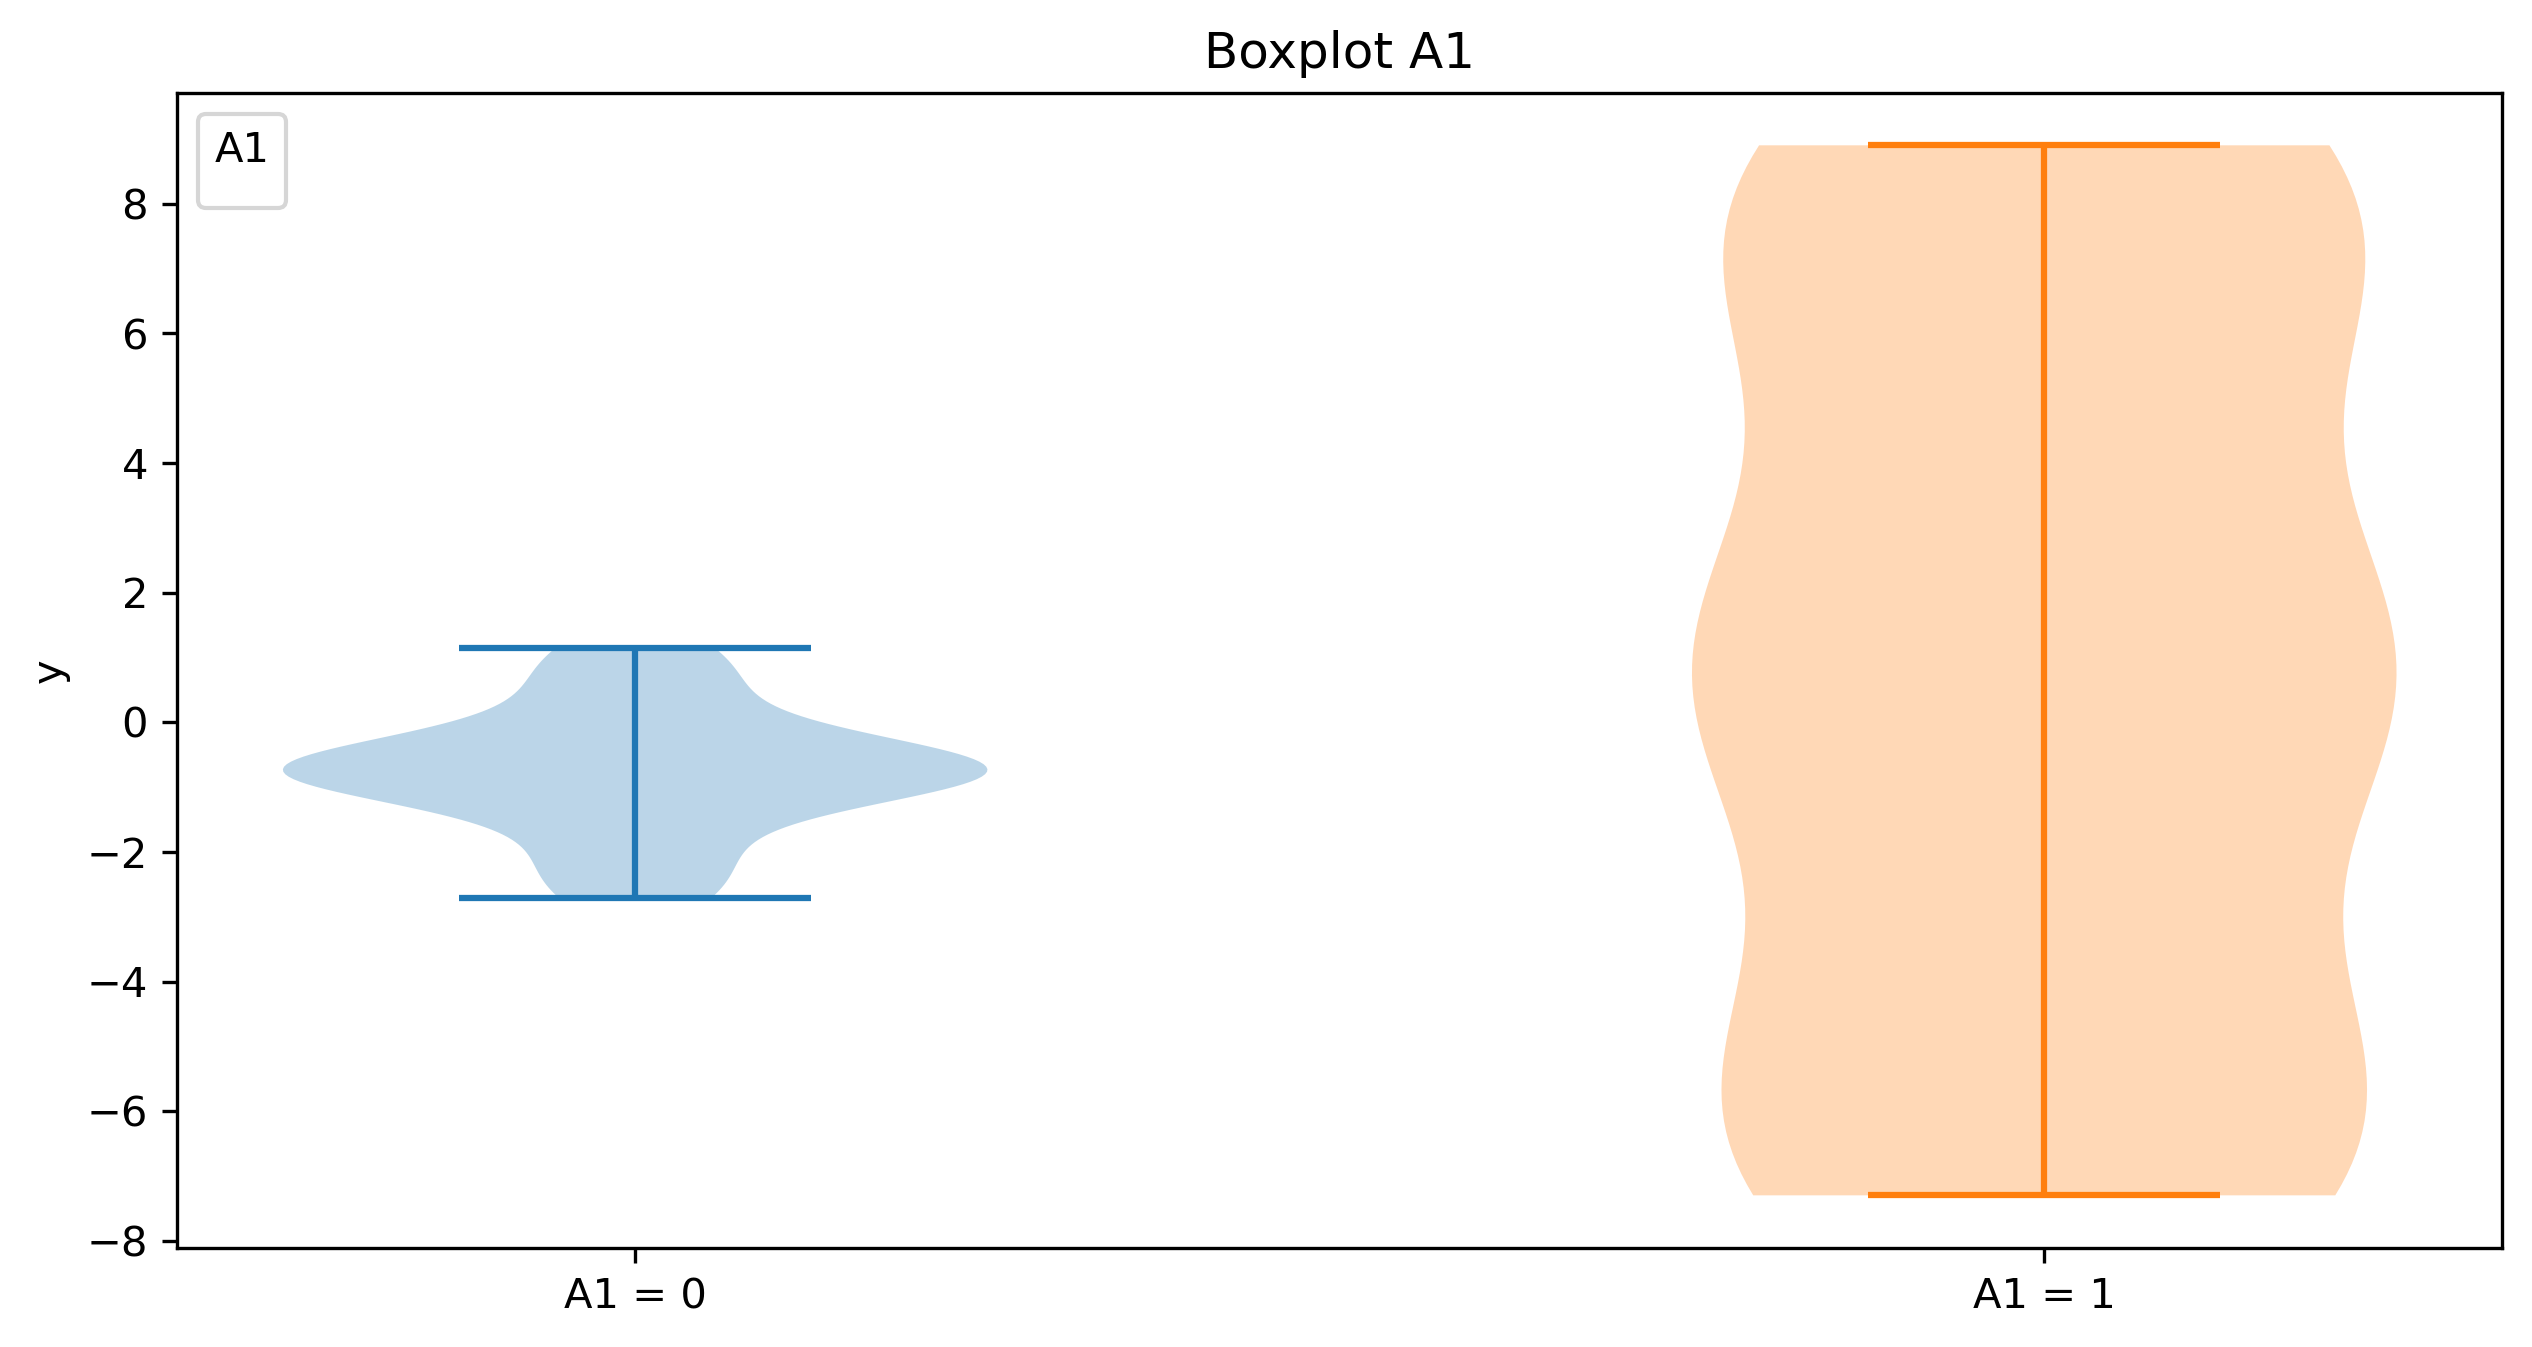

In [24]:
x1_0 = matriz_diseno_3[matriz_diseno_3['A1'] == 0]
x1_1 = matriz_diseno_3[matriz_diseno_3['A1'] == 1]

fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi = 300)
ax.violinplot(x1_0['y'], positions = [0])
ax.violinplot(x1_1['y'], positions = [1])
ax.set_xticks([0, 1])
ax.set_xticklabels(['A1 = 0', 'A1 = 1'])
ax.set_ylabel('y')
ax.set_title('Boxplot A1')
ax.legend(title='A1', loc='upper left')


Podemos ver que las distribuciones no son tan normales, ni homocedasticas. Por lo cuál es importante realizar un test no-paramétrico.

In [25]:
### Kurskal for diference in medians
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu

kruskal_A = kruskal(x1_0['y'], x1_1['y'])
print(f'Kruskal A1: {kruskal_A[1]}')
mannwhitney_A = mannwhitneyu(x1_0['y'], x1_1['y'], alternative='greater')
print(f'Mann Whitney A1 (A0 = 0 > A1 = 1 ): {mannwhitney_A[1]}')
mannwhitney_A = mannwhitneyu(x1_0['y'], x1_1['y'], alternative='less')
print(f'Mann Whitney A1 (A0 = 0 < A1 = 1 ): {mannwhitney_A[1]}')

Kruskal A1: 0.04264072264009575
Mann Whitney A1 (A0 = 0 > A1 = 1 ): 0.9789658205124703
Mann Whitney A1 (A0 = 0 < A1 = 1 ): 0.021609828777667928


Probemos ahora al comparar los diferentes grupos de B.

Text(0.5, 1.0, 'Boxplot B1')

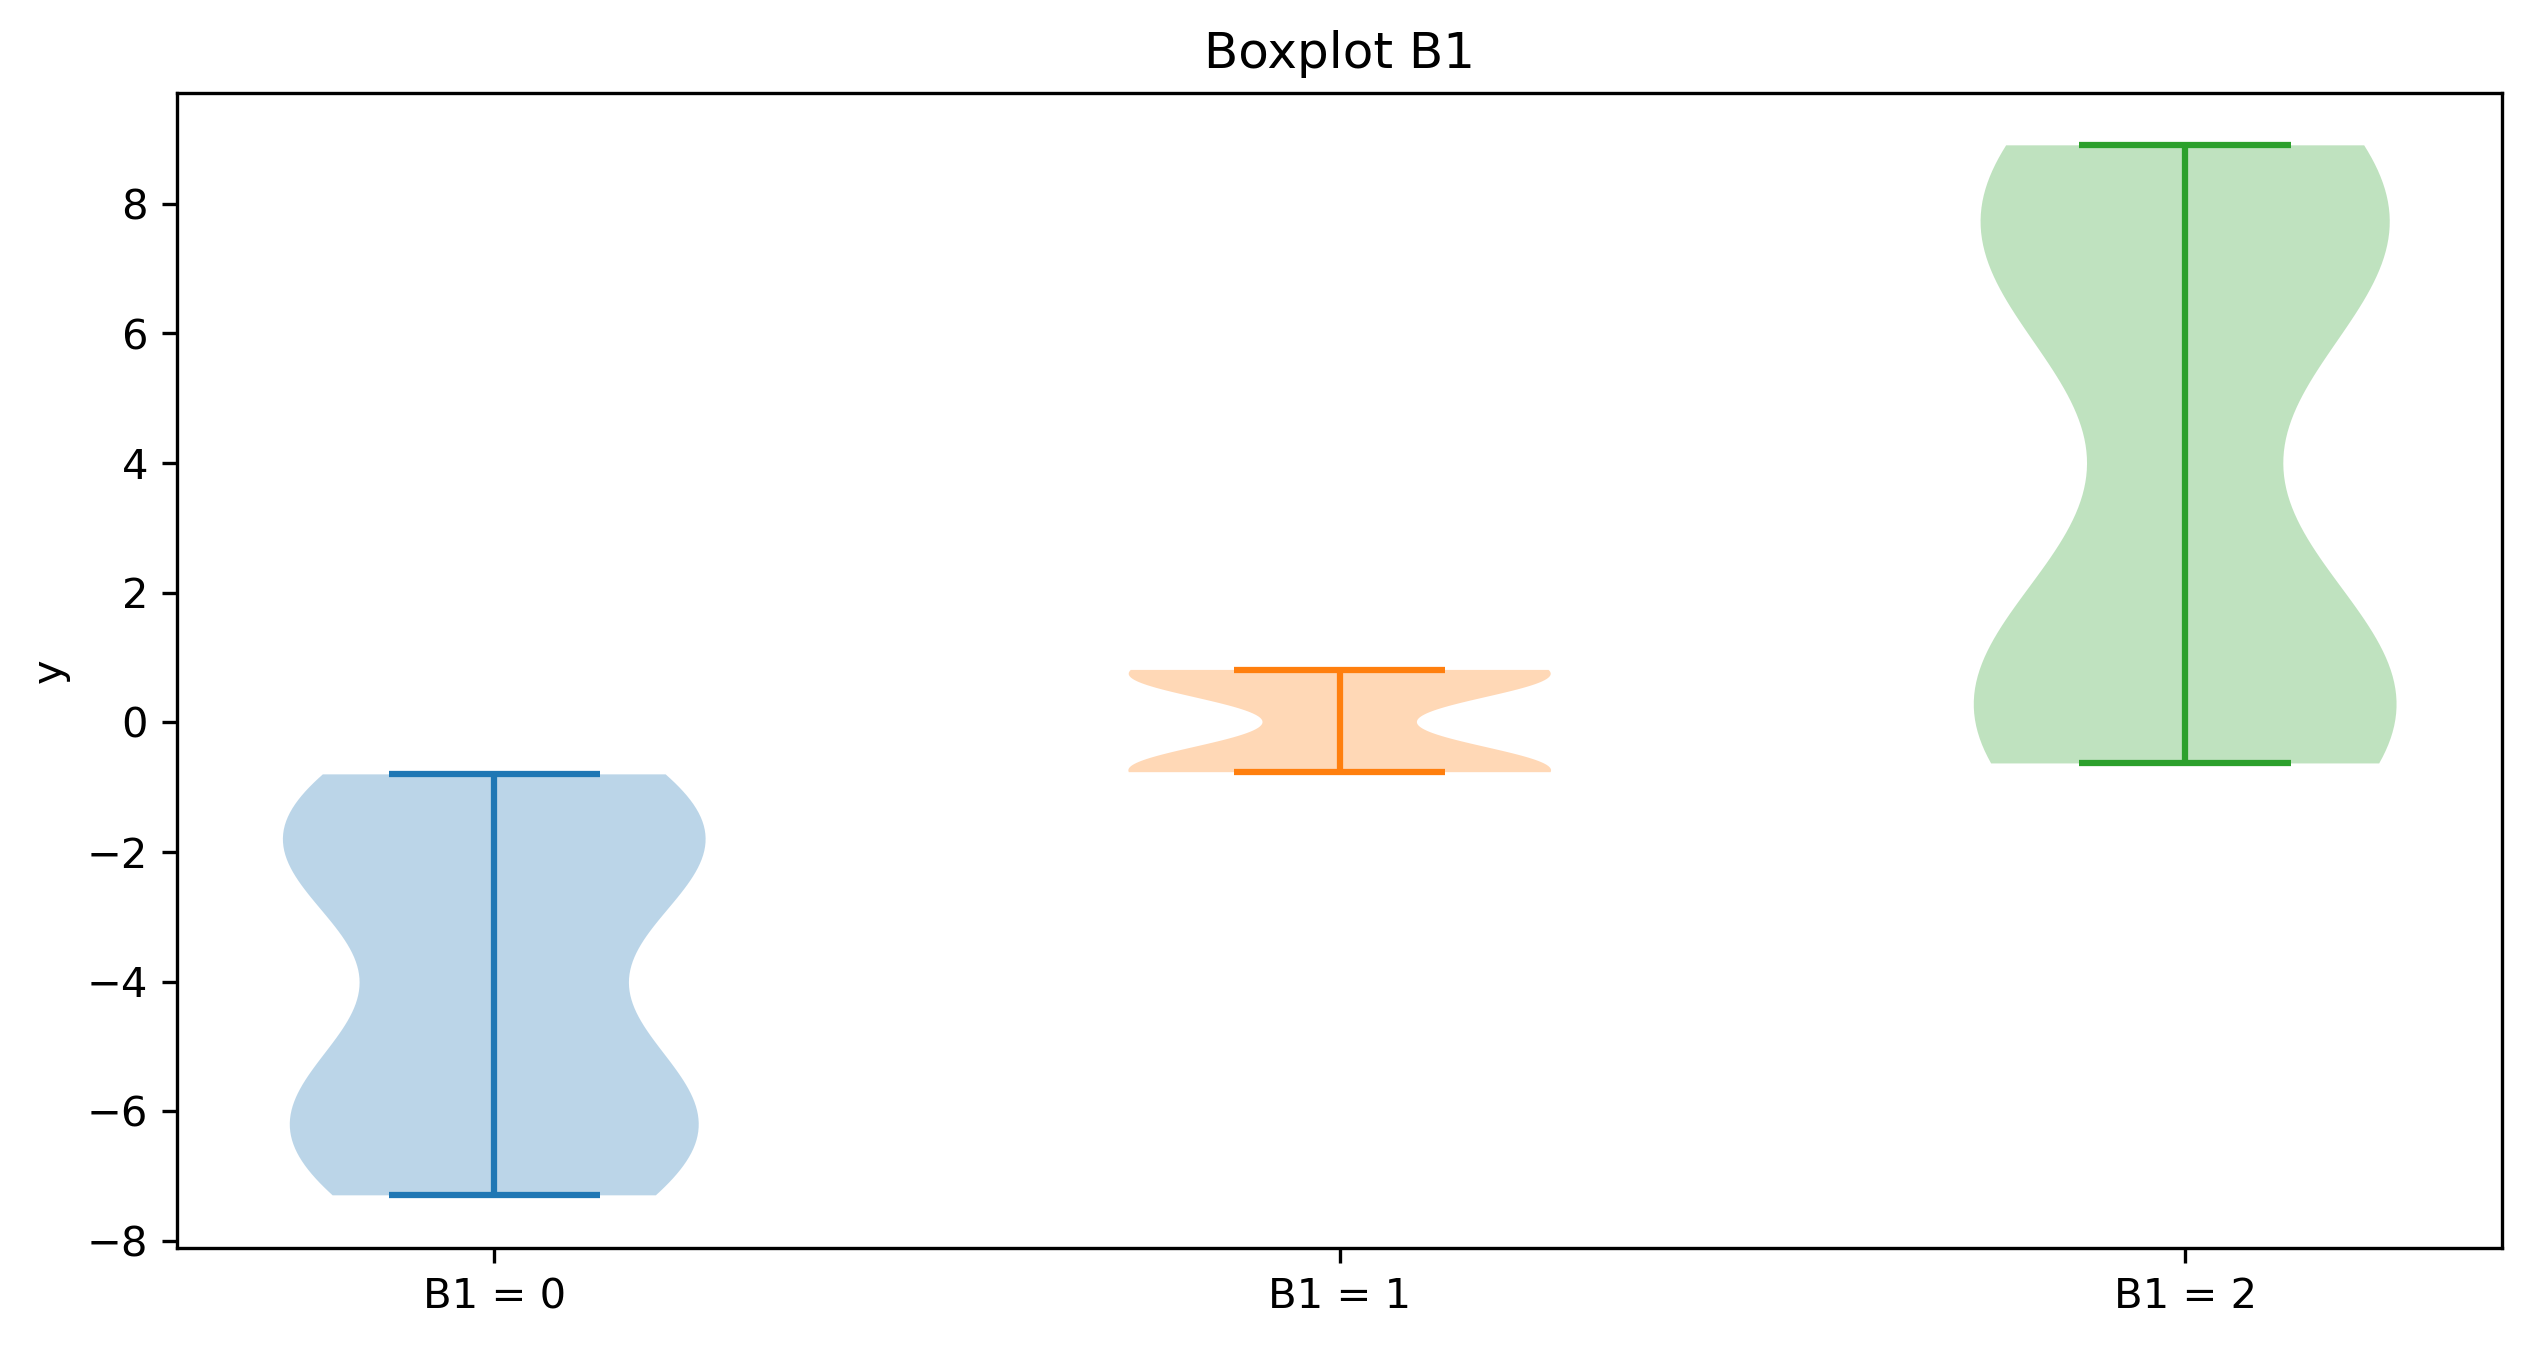

In [26]:
x2_0 = matriz_diseno_3[matriz_diseno_3['B1'] == 0]
x2_1 = matriz_diseno_3[matriz_diseno_3['B1'] == 1]
x2_2 = matriz_diseno_3[matriz_diseno_3['B1'] == 2]

fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi = 300)
ax.violinplot(x2_0['y'], positions = [0])
ax.violinplot(x2_1['y'], positions = [1])
ax.violinplot(x2_2['y'], positions = [2])
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['B1 = 0', 'B1 = 1', 'B1 = 2'])
ax.set_ylabel('y')
ax.set_title('Boxplot B1')



Podemos ver a simple vista que los grupos no son normales. Así que denuevo recurrimos a pruebas no paramétricas.

In [27]:
# vemos 

kurskal_B = kruskal(x2_0['y'], x2_1['y'], x2_2['y'])
print(f'Kruskal B1: {kurskal_B[1]}')

Kruskal B1: 2.4051119669882993e-12


Ahora podemos realizar un test no-parametrico de forma pareada para comparar las diferentes
medias y asi evaluar los efectos de los tratamientos.

`pingouin.pairwise_tests(parametric=False)` ejecuta Mann-Whitney U entre cada par de grupos y
reporta el **tamano del efecto de Hedges' g**: una version estandarizada mas robusta que Cohen's d
cuando los grupos tienen distintos tamanhos o varianzas. Escala de referencia:
$|g| \approx 0.2$ = pequeno, $|g| \approx 0.5$ = mediano, $|g| \approx 0.8$ = grande.

In [28]:
# prueba mannwhitney pairwise
import pingouin as pg

pg.pairwise_tests(dv = 'y', between = 'B1', data = matriz_diseno_3, parametric=False, alternative = 'less')


,Contrast,A,B,Paired,Parametric,U_val,alternative,p_unc,hedges
0,B1,0,1,False,False,0.0,less,1.531832e-09,-2.196448
1,B1,0,2,False,False,0.0,less,1.531832e-09,-2.423226
2,B1,1,2,False,False,108.0,less,1.072794e-04,-1.397225


En este caso, se nos da confianza que lo que se pudo ver en el gráfico es real. Y en realidad se tiene que para los diferentes B, el efecto de 0 es menor a 1 y este último a 2. Es decir, $B_0 < B_1 < B_2$.

## Estimación de Efecto

> Estime los parámetros del modelo de efectos principales e interacciones (solo entre $x_1$ y $x_2$). ¿Cuál variable tiene mayor efecto sobre la respuesta?

Realizamos un procedimiento similar al que se realizó previamente para estimar los efectos de las variables. Con esto obtenemos:

In [29]:
mu = matriz_diseno_3['y'].mean()
A_means = matriz_diseno_3.groupby('A1', observed=True)['y'].mean()
B_means = matriz_diseno_3.groupby('B1', observed=True)['y'].mean()
AB_means = matriz_diseno_3.groupby(['A1', 'B1'], observed=True)['y'].mean()
A_effect = A_means - mu
B_effect = B_means - mu
interactions_AB = (
    AB_means
    - A_means
    - B_means
    + mu
)

print('Grand Mean')
display(mu)
print('Factor A')
display(A_effect)
print('Factor B')
display(B_effect)
print('Interaction AB')
display(interactions_AB)

Grand Mean


np.float64(0.0012034635452288593)

Factor A


A1
0   -0.748614
1    0.748614
Name: y, dtype: float64

Factor B


B1
0   -4.002660
1    0.002799
2    3.999861
Name: y, dtype: float64

Interaction AB


A1  B1
0   0     2.997857
    1     0.001234
    2    -2.999090
1   0    -2.997857
    1    -0.001234
    2     2.999090
Name: y, dtype: float64

**Interpretacion de los efectos en el modelo reducido (solo A y B):**

- El efecto de **B** (~4 por nivel) es mucho mayor que el de **A** (~0.75): B es el factor dominante.
- La **interaccion A:B** (~3) tiene magnitud comparable al efecto de B, lo que indica que el impacto
  de A sobre la respuesta cambia fuertemente segun el nivel de B (lineas no paralelas en el
  interaction plot). Ignorar esta interaccion llevaria a conclusiones erroneas sobre A.
- Estos valores son consistentes con los pesos del modelo generador ($w_2 = 4,\ w_1 = 0.75,\ w_{12} = 3$)
  y confirman que el analisis estadistico recupero la estructura del experimento.